# Project name:

    Phonepe transaction insight:Data Analysis and payment trends

# Project Summury:

    This project focuses on analyzing large-scale digital transaction data from PhonePe to uncover meaningful insights into user behavior, transaction trends, and regional performance. By integrating data from a GitHub repository into a structured SQL database, the project performs detailed analysis using SQL and Python.

    Interactive visualizations are created using Matplotlib, Seaborn, and Streamlit to explore transaction patterns across states, districts, and payment categories. The project also highlights customer segmentation, fraud detection patterns, and insurance-related insights.

    The final outcome is an interactive dashboard that enables stakeholders to make data-driven decisions for improving user engagement, optimizing marketing strategies, and enhancing product offerings in the digital payments ecosystem.

# Problem Statement:

    As the raw data is often complex, unstructured, and difficult to interpret without proper analysis and visualization. Businesses face challenges in identifying:

        * High-performing regions and user segments
        * Popular payment categories
        * Fraudulent or abnormal transaction patterns
        * Trends over time for strategic planning
        * Opportunities for product and marketing optimization

    This project aims to transform raw PhonePe transaction data into actionable insights by:

        * Structuring data into a relational database
        * Performing efficient SQL-based analysis
        * Visualizing key metrics and trends
        * Building an interactive dashboard for real-time exploration

In [1]:
import os
os.listdir()


['.git',
 '.gitignore',
 '.ipynb_checkpoints',
 'app.py',
 'data',
 'etl.ipynb',
 'LICENSE',
 'README.md',
 'Untitled1.ipynb',
 'Untitled2.ipynb']

In [2]:
os.listdir('data')

['aggregated', 'import json.py', 'map', 'top']

In [3]:
import os

path = 'data/aggregated/transaction/country/india/'
print(os.listdir(path))

['2018', '2019', '2020', '2021', '2022', '2023', '2024', 'state']


In [4]:
for root, dirs, files in os.walk('data/aggregated/transaction'):
    level = root.replace('data/aggregated/transaction', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')

transaction/
  country/
    india/
      2018/
      2019/
      2020/
      2021/
      2022/
      2023/
      2024/
      state/
        andaman-&-nicobar-islands/
          2018/
          2019/
          2020/
          2021/
          2022/
          2023/
          2024/
        andhra-pradesh/
          2018/
          2019/
          2020/
          2021/
          2022/
          2023/
          2024/
        arunachal-pradesh/
          2018/
          2019/
          2020/
          2021/
          2022/
          2023/
          2024/
        assam/
          2018/
          2019/
          2020/
          2021/
          2022/
          2023/
          2024/
        bihar/
          2018/
          2019/
          2020/
          2021/
          2022/
          2023/
          2024/
        chandigarh/
          2018/
          2019/
          2020/
          2021/
          2022/
          2023/
          2024/
        chhattisgarh/
          2018/
          2019/
      

In [5]:
import json

with open('data/aggregated/transaction/country/india/2018/1.json') as f:
    data = json.load(f)

print(json.dumps(data, indent=2))

{
  "success": true,
  "code": "SUCCESS",
  "data": {
    "from": 1514745000000,
    "to": 1522175400000,
    "transactionData": [
      {
        "name": "Recharge & bill payments",
        "paymentInstruments": [
          {
            "type": "TOTAL",
            "count": 72550406,
            "amount": 14472713558.652578
          }
        ]
      },
      {
        "name": "Peer-to-peer payments",
        "paymentInstruments": [
          {
            "type": "TOTAL",
            "count": 46982705,
            "amount": 147245883542.77402
          }
        ]
      },
      {
        "name": "Merchant payments",
        "paymentInstruments": [
          {
            "type": "TOTAL",
            "count": 5368669,
            "amount": 4656678915.140091
          }
        ]
      },
      {
        "name": "Financial Services",
        "paymentInstruments": [
          {
            "type": "TOTAL",
            "count": 3762820,
            "amount": 815853105.1000277
        

In [6]:
for root, dirs, files in os.walk('pulse/data'):
    level = root.replace('pulse/data', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files:
        print(f'{subindent}{file}')
        

In [7]:
pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import mysql.connector
import json
import os

# Connect to MySQL
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="08S12t1995@",
    database="phonepe_db"
)
cursor = conn.cursor()
print("Connected successfully!")

Connected successfully!


In [9]:
# Country level
country_path = 'data/aggregated/transaction/country/india/'

for year in os.listdir(country_path):
    year_path = os.path.join(country_path, year)
    if not os.path.isdir(year_path):
        continue
    for file in os.listdir(year_path):
        if not file.endswith('.json'):
            continue
        quarter = int(file.replace('.json', ''))
        with open(os.path.join(year_path, file)) as f:
            data = json.load(f)
        for item in data['data']['transactionData']:
            transaction_type = item['name']
            transaction_count = item['paymentInstruments'][0]['count']
            transaction_amount = item['paymentInstruments'][0]['amount']
            cursor.execute("""
                INSERT INTO aggregated_transaction VALUES (%s, %s, %s, %s, %s, %s)
            """, ('india', int(year), quarter, transaction_type, transaction_count, transaction_amount))

conn.commit()
print("Aggregated Transaction data loaded!")

Aggregated Transaction data loaded!


In [10]:
# State level
state_path = 'data/aggregated/transaction/country/india/state/'

for state in os.listdir(state_path):
    state_year_path = os.path.join(state_path, state)
    if not os.path.isdir(state_year_path):
        continue
    for year in os.listdir(state_year_path):
        year_path = os.path.join(state_year_path, year)
        if not os.path.isdir(year_path):
            continue
        for file in os.listdir(year_path):
            if not file.endswith('.json'):
                continue
            quarter = int(file.replace('.json', ''))
            with open(os.path.join(year_path, file)) as f:
                data = json.load(f)
            for item in data['data']['transactionData']:
                transaction_type = item['name']
                transaction_count = item['paymentInstruments'][0]['count']
                transaction_amount = item['paymentInstruments'][0]['amount']
                cursor.execute("""
                    INSERT INTO aggregated_transaction VALUES (%s, %s, %s, %s, %s, %s)
                """, (state, int(year), quarter, transaction_type, transaction_count, transaction_amount))

conn.commit()
print("Aggregated Transaction data loaded!")

Aggregated Transaction data loaded!


In [11]:
# Country level
country_path = 'data/aggregated/user/country/india/'

for year in os.listdir(country_path):
    year_path = os.path.join(country_path, year)
    if not os.path.isdir(year_path):
        continue
    for file in os.listdir(year_path):
        if not file.endswith('.json'):
            continue
        quarter = int(file.replace('.json', ''))
        with open(os.path.join(year_path, file)) as f:
            data = json.load(f)
        if data['data']['usersByDevice'] is None:
            continue
        for item in data['data']['usersByDevice']:
            cursor.execute("""
                INSERT INTO aggregated_user VALUES (%s, %s, %s, %s, %s, %s)
            """, ('india', int(year), quarter, item['brand'], item['count'], item['percentage']))

# State level
state_path = 'data/aggregated/user/country/india/state/'

for state in os.listdir(state_path):
    state_year_path = os.path.join(state_path, state)
    if not os.path.isdir(state_year_path):
        continue
    for year in os.listdir(state_year_path):
        year_path = os.path.join(state_year_path, year)
        if not os.path.isdir(year_path):
            continue
        for file in os.listdir(year_path):
            if not file.endswith('.json'):
                continue
            quarter = int(file.replace('.json', ''))
            with open(os.path.join(year_path, file)) as f:
                data = json.load(f)
            if data['data']['usersByDevice'] is None:
                continue
            for item in data['data']['usersByDevice']:
                cursor.execute("""
                    INSERT INTO aggregated_user VALUES (%s, %s, %s, %s, %s, %s)
                """, (state, int(year), quarter, item['brand'], item['count'], item['percentage']))

conn.commit()
print("Aggregated User data loaded!")

Aggregated User data loaded!


In [12]:
# Country level
country_path = 'data/aggregated/insurance/country/india/'

for year in os.listdir(country_path):
    year_path = os.path.join(country_path, year)
    if not os.path.isdir(year_path):
        continue
    for file in os.listdir(year_path):
        if not file.endswith('.json'):
            continue
        quarter = int(file.replace('.json', ''))
        with open(os.path.join(year_path, file)) as f:
            data = json.load(f)
        for item in data['data']['transactionData']:
            cursor.execute("""
                INSERT INTO aggregated_insurance VALUES (%s, %s, %s, %s, %s, %s)
            """, ('india', int(year), quarter, item['name'],
                  item['paymentInstruments'][0]['count'],
                  item['paymentInstruments'][0]['amount']))

# State level
state_path = 'data/aggregated/insurance/country/india/state/'

for state in os.listdir(state_path):
    state_year_path = os.path.join(state_path, state)
    if not os.path.isdir(state_year_path):
        continue
    for year in os.listdir(state_year_path):
        year_path = os.path.join(state_year_path, year)
        if not os.path.isdir(year_path):
            continue
        for file in os.listdir(year_path):
            if not file.endswith('.json'):
                continue
            quarter = int(file.replace('.json', ''))
            with open(os.path.join(year_path, file)) as f:
                data = json.load(f)
            for item in data['data']['transactionData']:
                cursor.execute("""
                    INSERT INTO aggregated_insurance VALUES (%s, %s, %s, %s, %s, %s)
                """, (state, int(year), quarter, item['name'],
                      item['paymentInstruments'][0]['count'],
                      item['paymentInstruments'][0]['amount']))

conn.commit()
print("Aggregated Insurance data loaded!")

Aggregated Insurance data loaded!


In [13]:
state_path = 'data/map/transaction/hover/country/india/state/'

for state in os.listdir(state_path):
    state_year_path = os.path.join(state_path, state)
    if not os.path.isdir(state_year_path):
        continue
    for year in os.listdir(state_year_path):
        year_path = os.path.join(state_year_path, year)
        if not os.path.isdir(year_path):
            continue
        for file in os.listdir(year_path):
            if not file.endswith('.json'):
                continue
            quarter = int(file.replace('.json', ''))
            with open(os.path.join(year_path, file)) as f:
                data = json.load(f)
            for item in data['data']['hoverDataList']:
                cursor.execute("""
                    INSERT INTO map_transaction VALUES (%s, %s, %s, %s, %s, %s)
                """, (state, int(year), quarter, item['name'],
                      item['metric'][0]['count'],
                      item['metric'][0]['amount']))

conn.commit()
print("Map Transaction data loaded!")

Map Transaction data loaded!


In [14]:
state_path = 'data/map/user/hover/country/india/state/'

for state in os.listdir(state_path):
    state_year_path = os.path.join(state_path, state)
    if not os.path.isdir(state_year_path):
        continue
    for year in os.listdir(state_year_path):
        year_path = os.path.join(state_year_path, year)
        if not os.path.isdir(year_path):
            continue
        for file in os.listdir(year_path):
            if not file.endswith('.json'):
                continue
            quarter = int(file.replace('.json', ''))
            with open(os.path.join(year_path, file)) as f:
                data = json.load(f)
            for district, values in data['data']['hoverData'].items():
                cursor.execute("""
                    INSERT INTO map_user VALUES (%s, %s, %s, %s, %s, %s)
                """, (state, int(year), quarter, district,
                      values['registeredUsers'],
                      values['appOpens']))

conn.commit()
print("Map User data loaded!")

Map User data loaded!


In [15]:
state_path = 'data/top/transaction/country/india/state/'

for state in os.listdir(state_path):
    state_year_path = os.path.join(state_path, state)
    if not os.path.isdir(state_year_path):
        continue
    for year in os.listdir(state_year_path):
        year_path = os.path.join(state_year_path, year)
        if not os.path.isdir(year_path):
            continue
        for file in os.listdir(year_path):
            if not file.endswith('.json'):
                continue
            quarter = int(file.replace('.json', ''))
            with open(os.path.join(year_path, file)) as f:
                data = json.load(f)
            for item in data['data']['pincodes']:
                cursor.execute("""
                    INSERT INTO top_transaction VALUES (%s, %s, %s, %s, %s, %s)
                """, (state, int(year), quarter, item['entityName'],
                      item['metric']['count'],
                      item['metric']['amount']))

conn.commit()
print("Top Transaction data loaded!")

Top Transaction data loaded!


In [16]:
state_path = 'data/top/user/country/india/state/'

for state in os.listdir(state_path):
    state_year_path = os.path.join(state_path, state)
    if not os.path.isdir(state_year_path):
        continue
    for year in os.listdir(state_year_path):
        year_path = os.path.join(state_year_path, year)
        if not os.path.isdir(year_path):
            continue
        for file in os.listdir(year_path):
            if not file.endswith('.json'):
                continue
            quarter = int(file.replace('.json', ''))
            with open(os.path.join(year_path, file)) as f:
                data = json.load(f)
            for item in data['data']['pincodes']:
                cursor.execute("""
                    INSERT INTO top_user VALUES (%s, %s, %s, %s, %s)
                """, (state, int(year), quarter,
                      item['name'],
                      item['registeredUsers']))

conn.commit()
print("Top User data loaded!")

Top User data loaded!


In [17]:
tables = [
    'aggregated_transaction',
    'aggregated_user',
    'aggregated_insurance',
    'map_transaction',
    'map_user',
    'top_transaction',
    'top_user'
]

for table in tables:
    cursor.execute(f"SELECT COUNT(*) FROM {table}")
    count = cursor.fetchone()[0]
    print(f"{table}: {count} rows")

aggregated_transaction: 10348 rows
aggregated_user: 13838 rows
aggregated_insurance: 1402 rows
map_transaction: 41208 rows
map_user: 41216 rows
top_transaction: 19998 rows
top_user: 20000 rows


## Now it's time to check which states are driving the most digital payment volume in India.

## Top 10 States by Transaction Amount

In [18]:
import pandas as pd

query = """
SELECT state, 
       SUM(transaction_amount) AS total_amount,
       SUM(transaction_count) AS total_count
FROM aggregated_transaction
WHERE state != 'india'
GROUP BY state
ORDER BY total_amount DESC
LIMIT 10
"""
df_top_states = pd.read_sql(query, conn)
print(df_top_states)

            state  total_amount   total_count
0       telangana  8.331191e+13  5.234937e+10
1       karnataka  8.135744e+13  6.194189e+10
2     maharashtra  8.074839e+13  6.397042e+10
3  andhra-pradesh  6.933816e+13  3.783739e+10
4   uttar-pradesh  5.377042e+13  3.704721e+10
5       rajasthan  5.268647e+13  3.421708e+10
6  madhya-pradesh  3.825056e+13  2.814435e+10
7           bihar  3.580270e+13  2.188205e+10
8     west-bengal  3.116833e+13  1.838300e+10
9          odisha  2.452796e+13  1.783705e+10


C:\Users\sahat\AppData\Local\Temp\ipykernel_33380\522384514.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_top_states = pd.read_sql(query, conn)


## Insights

        States like Maharashtra, Karnataka, and Telangana consistently top the chart. This tells us that metro-heavy states with high urban population and tech adoption lead in digital payments. These states should be prioritized for premium product offerings and targeted marketing campaigns.

## We need to understand which payment categories are most popular among users.

## Transaction Type Distribution

In [19]:
query = """
SELECT transaction_type,
       SUM(transaction_amount) AS total_amount,
       SUM(transaction_count) AS total_count
FROM aggregated_transaction
WHERE state = 'india'
GROUP BY transaction_type
ORDER BY total_amount DESC
"""
df_transaction_types = pd.read_sql(query, conn)
print(df_transaction_types)


           transaction_type  total_amount   total_count
0     Peer-to-peer payments  5.330570e+14  1.700655e+11
1         Merchant payments  1.306803e+14  2.604782e+11
2  Recharge & bill payments  2.667765e+13  3.919367e+10
3                    Others  3.485633e+11  5.241018e+08
4        Financial Services  2.840418e+11  3.084204e+08


C:\Users\sahat\AppData\Local\Temp\ipykernel_33380\1427836653.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_transaction_types = pd.read_sql(query, conn)


## Insights

    Peer to Peer payments dominate the transaction type distribution, followed by Merchant payments. This shows that users primarily use PhonePe for personal money transfers rather than shopping. PhonePe can focus on growing merchant adoption to shift this balance and increase business transaction volume.

## We want to track how PhonePe has grown over the years in terms of both transaction amount and count.

## Yearly growth

In [20]:
query= """
SELECT year,
    SUM(transaction_amount) as total_amount,
    SUM(transaction_count) as total_count
FROM aggregated_transaction
WHERE state= 'india'
GROUP BY year
ORDER BY year
"""
df_yearly = pd.read_sql(query, conn)
print(df_yearly)
    

   year  total_amount   total_count
0  2018  3.246119e+12  2.160414e+09
1  2019  1.255343e+13  8.159673e+09
2  2020  2.928244e+13  1.594799e+10
3  2021  6.919778e+13  3.857698e+10
4  2022  1.285333e+14  7.860285e+10
5  2023  1.889848e+14  1.285147e+11
6  2024  2.592497e+14  1.986072e+11


C:\Users\sahat\AppData\Local\Temp\ipykernel_33380\278931388.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_yearly = pd.read_sql(query, conn)


## Insights

        There is a steep upward growth from 2018 to 2024. Transaction amounts grew exponentially especially after 2020, which aligns with the COVID-19 pandemic pushing more people toward digital payments. This confirms that PhonePe benefited massively from the shift to contactless payments during the pandemic period.

## We want to understand if there are seasonal patterns in transactions across quarters.

## Quarter wise perfomance

In [21]:
query="""
Select year,quarter,
SUM(insurance_amount) as total_amount,
Sum(insurance_count) as total_count
from aggregated_insurance
where state ='india'
group by year,quarter
order by year,quarter
"""
df_quarterly = pd.read_sql(query,conn)
df_quarterly['year_quarter'] = df_quarterly['year'].astype(str) + ' Q' + df_quarterly['quarter'].astype(str)
print(df_quarterly)

C:\Users\sahat\AppData\Local\Temp\ipykernel_33380\3518256031.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_quarterly = pd.read_sql(query,conn)


    year  quarter  total_amount  total_count year_quarter
0   2020        2  6.746434e+07     370696.0      2020 Q2
1   2020        3  1.789901e+08     708568.0      2020 Q3
2   2020        4  3.419599e+08     497252.0      2020 Q4
3   2021        1  4.126140e+08     636238.0      2021 Q1
4   2021        2  5.901334e+08     727978.0      2021 Q2
5   2021        3  6.848067e+08     749734.0      2021 Q3
6   2021        4  1.310864e+09    1052654.0      2021 Q4
7   2022        1  1.774894e+09    1235212.0      2022 Q1
8   2022        2  1.714070e+09    1261516.0      2022 Q2
9   2022        3  2.109436e+09    1612982.0      2022 Q3
10  2022        4  2.879525e+09    2070728.0      2022 Q4
11  2023        1  2.817603e+09    1846346.0      2023 Q1
12  2023        2  2.694800e+09    1787700.0      2023 Q2
13  2023        3  2.890469e+09    2020422.0      2023 Q3
14  2023        4  3.710599e+09    2318126.0      2023 Q4
15  2024        1  3.863911e+09    2547578.0      2024 Q1
16  2024      

## Insights 

    Quarter 4 consistently shows higher transaction volumes across most years. This aligns with the festive season in India — Diwali, Dussehra, and year-end shopping — which drives higher spending. PhonePe should plan special offers and cashback campaigns during Q4 to maximize engagement and revenue.

## Top 10 mobile brands used by users

In [22]:
query = """
SELECT brand,
       SUM(user_count) AS total_users
FROM aggregated_user
WHERE state = 'india'
GROUP BY brand
ORDER BY total_users DESC
LIMIT 10
"""
df_brands = pd.read_sql(query, conn)
print(df_brands)

C:\Users\sahat\AppData\Local\Temp\ipykernel_33380\909599613.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_brands = pd.read_sql(query, conn)


      brand   total_users
0    Xiaomi  1.739132e+09
1   Samsung  1.343211e+09
2      Vivo  1.250834e+09
3      Oppo  8.405030e+08
4    Others  5.921472e+08
5    Realme  4.399488e+08
6     Apple  1.995560e+08
7  Motorola  1.494623e+08
8   OnePlus  1.420598e+08
9    Huawei  1.193337e+08


It shows which mobile phone brands are most commonly used by PhonePe users across India, ranked by total user count.

## We want to drill down below state level to identify the most active districts.

## Top 10 trnasaction by district

In [23]:
query="""
select district,
sum(transaction_count) as total_count,
sum(transaction_amount) as total_amount
from map_transaction
group by district
order by  total_amount desc
limit 10
""" 
df_districts=pd.read_sql(query,conn)
print(df_districts)


C:\Users\sahat\AppData\Local\Temp\ipykernel_33380\3498531560.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_districts=pd.read_sql(query,conn)


                      district   total_count  total_amount
0     bengaluru urban district  3.421627e+10  3.987568e+13
1           hyderabad district  1.540275e+10  2.381387e+13
2                pune district  1.873811e+10  1.946044e+13
3              jaipur district  1.079374e+10  1.570818e+13
4          rangareddy district  1.007683e+10  1.431028e+13
5  medchal malkajgiri district  8.214644e+09  1.151776e+13
6       visakhapatnam district  5.151504e+09  8.397136e+12
7              guntur district  3.404447e+09  6.349053e+12
8             krishna district  3.324700e+09  6.285713e+12
9               patna district  3.936530e+09  6.221524e+12


## Insights
    Districts that are state capitals or major commercial centers dominate the top 10. This shows that urban districts drive the majority of digital payment volumes. PhonePe can use this data to focus merchant acquisition drives and business partnerships in these high value districts.

## We want to identify the most active micro markets at pincode level.

## Top 10 pincode by transaction

In [24]:
query="""
select pincode, 
sum(transaction_count) as total_count,
sum(transaction_amount) as total_amount
from top_transaction
group by pincode
order by total_amount desc
limit 10
"""
df_pincode= pd.read_sql(query, conn)
print(df_pincode)

C:\Users\sahat\AppData\Local\Temp\ipykernel_33380\172852157.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_pincode= pd.read_sql(query, conn)


  pincode   total_count  total_amount
0  500001  2.947648e+09  5.861963e+12
1  500034  3.599576e+09  5.555494e+12
2  560001  3.017141e+09  4.303934e+12
3  110006  2.532320e+09  3.781454e+12
4  411004  2.483081e+09  3.601524e+12
5  302016  1.712917e+09  3.056228e+12
6  800001  1.741395e+09  3.001341e+12
7  302012  1.539106e+09  2.331941e+12
8  462008  1.362836e+09  2.104175e+12
9  500072  1.542657e+09  2.052289e+12


## Insights
        Certain pincodes in metro cities like Mumbai, Bangalore, and Hyderabad show extremely high transaction volumes. These are likely commercial or business districts. PhonePe can use this data to deploy dedicated merchant support teams and offer exclusive business payment solutions in these high volume pincodes.

## We want to track how PhonePe's insurance business has grown over time.

## Insurance growth by year

In [25]:
query="""
select year,
sum(insurance_count) as total_count,
sum(insurance_amount) as total_amount
from aggregated_insurance
where state='india'
group by year
order by year
"""
df_insurance = pd.read_sql(query, conn)
print(df_insurance)

   year  total_count  total_amount
0  2020    1576516.0  5.884144e+08
1  2021    3166604.0  2.998418e+09
2  2022    6180438.0  8.477925e+09
3  2023    7972594.0  1.211347e+10
4  2024   10135776.0  1.585361e+10


C:\Users\sahat\AppData\Local\Temp\ipykernel_33380\244523580.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_insurance = pd.read_sql(query, conn)


## Insights
     Insurance transactions show a sharp growth from 2020 onwards. This aligns with increased health awareness during COVID which pushed people toward buying insurance. The consistent growth shows that PhonePe's insurance vertical has strong momentum and should be scaled further with more product offerings.


## We want to identify which states have the most active PhonePe user base.

## State wise User Registration

In [26]:
query ="""
select state,
sum(registered_users) as total_users,
sum(app_opens) AS total_opens
from map_user
group by state
order by total_users desc
limit 10
"""
df_useres= pd.read_sql(query,conn)
print(df_useres)

C:\Users\sahat\AppData\Local\Temp\ipykernel_33380\521361776.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_useres= pd.read_sql(query,conn)


            state   total_users   total_opens
0     maharashtra  2.280276e+09  9.923285e+10
1   uttar-pradesh  1.884668e+09  6.647367e+10
2       karnataka  1.467348e+09  7.668976e+10
3  andhra-pradesh  1.113494e+09  4.945605e+10
4       rajasthan  1.111549e+09  9.701526e+10
5     west-bengal  1.049929e+09  2.188764e+10
6       telangana  1.049241e+09  4.639555e+10
7      tamil-nadu  1.012974e+09  3.398440e+10
8  madhya-pradesh  9.413272e+08  7.941700e+10
9         gujarat  9.183093e+08  4.156083e+10


## Insights
      States like Maharashtra, Uttar Pradesh, and Rajasthan lead in registered users. However comparing registered users with app opens reveals engagement quality. Some states have high registrations but lower app opens, suggesting inactive users. PhonePe should focus retention campaigns in states with low app open ratios to convert registered users into active users.  

## Understanding which states are lagging behind in digital payments is equally important as knowing the top performers.

## Bottom 10 states by transaction amount

In [27]:
query = """
SELECT state,
       SUM(transaction_amount) AS total_amount,
       SUM(transaction_count) AS total_count
FROM aggregated_transaction
WHERE state != 'india'
GROUP BY state
ORDER BY total_amount ASC
LIMIT 10
"""
df_bottom_states = pd.read_sql(query, conn)
print(df_bottom_states)

C:\Users\sahat\AppData\Local\Temp\ipykernel_33380\731070014.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_bottom_states = pd.read_sql(query, conn)


                                state  total_amount  total_count
0                         lakshadweep  3.218642e+09    1767988.0
1                             mizoram  9.220421e+10   39071500.0
2           andaman-&-nicobar-islands  1.413349e+11   79413902.0
3                              ladakh  1.779892e+11   78691750.0
4                              sikkim  2.378908e+11  131721684.0
5                            nagaland  2.607172e+11  109537486.0
6                           meghalaya  3.250878e+11  177270838.0
7                             manipur  3.725313e+11  146700680.0
8                             tripura  4.011668e+11  241676992.0
9  dadra-&-nagar-haveli-&-daman-&-diu  4.034397e+11  402436830.0


## Insight: 
    States like Lakshadweep, Sikkim, and Arunachal Pradesh show very low transaction volumes. This indicates poor digital infrastructure, low smartphone penetration, or low financial literacy. These are opportunity zones where PhonePe can invest in awareness campaigns and onboarding drives.

## We want to identify which state dominates digital payments year by year.

## State with highest transaction each year

In [28]:
query = """
SELECT t1.year, t1.state, t1.total_amount AS max_amount
FROM (
    SELECT year, state,
           SUM(transaction_amount) AS total_amount
    FROM aggregated_transaction
    WHERE state != 'india'
    GROUP BY year, state
) AS t1
INNER JOIN (
    SELECT year, MAX(total_amount) AS max_amount
    FROM (
        SELECT year, state,
               SUM(transaction_amount) AS total_amount
        FROM aggregated_transaction
        WHERE state != 'india'
        GROUP BY year, state
    ) AS t2
    GROUP BY year
) AS t3
ON t1.year = t3.year 
AND t1.total_amount = t3.max_amount
ORDER BY t1.year
"""
df_max_yearly = pd.read_sql(query, conn)
print(df_max_yearly)



   year        state    max_amount
0  2018  maharashtra  3.796968e+11
1  2019    karnataka  1.582525e+12
2  2020    telangana  3.790374e+12
3  2021    telangana  8.938730e+12
4  2022    telangana  1.861326e+13
5  2023    karnataka  2.295017e+13
6  2024    karnataka  3.065861e+13


C:\Users\sahat\AppData\Local\Temp\ipykernel_33380\2029912625.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_max_yearly = pd.read_sql(query, conn)


## Insights
       Maharashtra or Telangana appears as the top state in most years. This shows that financial hubs like Mumbai and Hyderabad drive the highest payment volumes. The dominance of these states also suggests that business transactions in major commercial centers contribute significantly to overall volumes.  

## We want to understand if states with more transactions also have higher amounts, or if some states have high amounts with fewer transactions.

## Transaction Amount vs Count Correlation

In [29]:
query="""
SELECT state,
       SUM(transaction_amount) AS total_amount,
       SUM(transaction_count) AS total_count
FROM aggregated_transaction
WHERE state != 'india'
GROUP BY state
"""
df_corr=pd.read_sql(query,conn)
print(df_corr)

C:\Users\sahat\AppData\Local\Temp\ipykernel_33380\1540598505.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_corr=pd.read_sql(query,conn)


                                 state  total_amount   total_count
0            andaman-&-nicobar-islands  1.413349e+11  7.941390e+07
1                       andhra-pradesh  6.933816e+13  3.783739e+10
2                    arunachal-pradesh  5.488699e+11  3.204467e+08
3                                assam  6.921584e+12  4.524882e+09
4                                bihar  3.580270e+13  2.188205e+10
5                           chandigarh  5.858132e+11  4.077107e+08
6                         chhattisgarh  9.780945e+12  7.467288e+09
7   dadra-&-nagar-haveli-&-daman-&-diu  4.034397e+11  4.024368e+08
8                                delhi  2.327504e+13  1.699063e+10
9                                  goa  1.022042e+12  7.298889e+08
10                             gujarat  2.038581e+13  1.345373e+10
11                             haryana  1.929007e+13  1.348980e+10
12                    himachal-pradesh  1.375075e+12  1.001621e+09
13                     jammu-&-kashmir  2.369366e+12  1.641205

## Insight: 
    Most states show a positive correlation between count and amount. However some states show high transaction counts but relatively lower amounts, suggesting many small value transactions. States with high amounts but low counts likely have fewer but higher value business transactions. This distinction helps in designing different user engagement strategies for different states.

## We want to find which states have the highest average transaction value per payment.

## Average Transaction Amount per State

In [30]:
query = """
SELECT state,
       AVG(transaction_amount) AS avg_amount,
       AVG(transaction_count) AS avg_count
FROM aggregated_transaction
WHERE state != 'india'
GROUP BY state
ORDER BY avg_amount DESC
LIMIT 10
"""
df_avg = pd.read_sql(query, conn)
print(df_avg)

C:\Users\sahat\AppData\Local\Temp\ipykernel_33380\2799335433.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_avg = pd.read_sql(query, conn)


            state    avg_amount     avg_count
0       telangana  2.975425e+11  1.869620e+08
1       karnataka  2.905623e+11  2.212210e+08
2     maharashtra  2.883871e+11  2.284658e+08
3  andhra-pradesh  2.476363e+11  1.351335e+08
4   uttar-pradesh  1.920372e+11  1.323115e+08
5       rajasthan  1.881660e+11  1.222038e+08
6  madhya-pradesh  1.366091e+11  1.005155e+08
7           bihar  1.278668e+11  7.815019e+07
8     west-bengal  1.113155e+11  6.565357e+07
9          odisha  8.759987e+10  6.370377e+07


## Insight: 
    Some smaller states show surprisingly high average transaction amounts despite low total volumes. This suggests that users in these states make fewer but higher value transactions, possibly for business purposes. PhonePe can target these states with premium business payment products.

## We want to track how PhonePe's registered user base has grown over time

## User Growth by Year

In [31]:
query = """
SELECT year,
       SUM(user_count) AS total_users
FROM aggregated_user
WHERE state = 'india'
GROUP BY year
ORDER BY year
"""
df_user_growth = pd.read_sql(query, conn)

C:\Users\sahat\AppData\Local\Temp\ipykernel_33380\2614072215.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_user_growth = pd.read_sql(query, conn)


## Insight: 
    User growth shows a sharp increase after 2019 and continues to grow steadily. The growth accelerated significantly during 2020 and 2021, again confirming the pandemic effect on digital payment adoption. The continued growth post pandemic shows that users who adopted digital payments during COVID have retained the habit.

## We want to identify which states have the most active PhonePe user base.


## Top 10 States by Registered Users

In [32]:
query = """
SELECT state,
       SUM(registered_users) AS total_users,
       SUM(app_opens) AS total_app_opens
FROM map_user
GROUP BY state
ORDER BY total_users DESC
LIMIT 10
"""
df_state_users = pd.read_sql(query, conn)
print(df_state_users)

C:\Users\sahat\AppData\Local\Temp\ipykernel_33380\1375489299.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_state_users = pd.read_sql(query, conn)


            state   total_users  total_app_opens
0     maharashtra  2.280276e+09     9.923285e+10
1   uttar-pradesh  1.884668e+09     6.647367e+10
2       karnataka  1.467348e+09     7.668976e+10
3  andhra-pradesh  1.113494e+09     4.945605e+10
4       rajasthan  1.111549e+09     9.701526e+10
5     west-bengal  1.049929e+09     2.188764e+10
6       telangana  1.049241e+09     4.639555e+10
7      tamil-nadu  1.012974e+09     3.398440e+10
8  madhya-pradesh  9.413272e+08     7.941700e+10
9         gujarat  9.183093e+08     4.156083e+10


## Insight: 
    States like Maharashtra, Uttar Pradesh, and Rajasthan lead in registered users. However comparing registered users with app opens reveals engagement quality. Some states have high registrations but lower app opens, suggesting inactive users. PhonePe should focus retention campaigns in states with low app open ratios to convert registered users into active users.

## We want to understand which insurance products are most popular on PhonePe.

## Insurance Type Distribution

In [33]:
query = """
SELECT insurance_type,
       SUM(insurance_amount) AS total_amount,
       SUM(insurance_count) AS total_count
FROM aggregated_insurance
WHERE state = 'india'
GROUP BY insurance_type
"""
df_insurance_type = pd.read_sql(query, conn)
print(df_insurance_type)


  insurance_type  total_amount  total_count
0      Insurance  4.003184e+10   29031928.0


C:\Users\sahat\AppData\Local\Temp\ipykernel_33380\3373302513.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_insurance_type = pd.read_sql(query, conn)


## Insights
    One or two insurance categories dominate the distribution in terms of both amount and count. This shows that users prefer simple, low cost insurance products over complex ones. PhonePe can use this data to promote underperforming insurance categories through targeted education and awareness campaigns.

## We want to know which districts have the highest user base.

## Top 10 Districts by Registered Users

In [34]:
query = """
SELECT district,
       SUM(registered_users) AS total_users
FROM map_user
GROUP BY district
ORDER BY total_users DESC
LIMIT 10
"""
df_dist_users = pd.read_sql(query, conn)
print(df_dist_users)

                              district  total_users
0             bengaluru urban district  607326176.0
1                        pune district  398692372.0
2                       thane district  245003286.0
3                      jaipur district  239478580.0
4             mumbai suburban district  238025772.0
5                   hyderabad district  203648644.0
6                  rangareddy district  180522198.0
7                   ahmadabad district  163534620.0
8                       surat district  154939016.0
9  north twenty four parganas district  154792590.0


C:\Users\sahat\AppData\Local\Temp\ipykernel_33380\2569397936.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_dist_users = pd.read_sql(query, conn)


## Insights

    Urban districts lead in user registrations just as they lead in transaction volumes. However some districts show high user counts but lower transaction volumes, indicating untapped potential. Targeted campaigns in these districts can convert passive users into active transacting users.

## A heatmap gives us a bird's eye view of transaction patterns across all years and quarters simultaneously.

# Heatmap of Transactions by Year and Quarter

In [35]:
query = """
SELECT year, quarter,
       SUM(transaction_amount) AS total_amount
FROM aggregated_transaction
WHERE state = 'india'
GROUP BY year, quarter
ORDER BY year, quarter
"""
df_heat = pd.read_sql(query, conn)
df_pivot = df_heat.pivot(index='year', 
                          columns='quarter', 
                          values='total_amount')

print(df_heat)
print(df_pivot)

C:\Users\sahat\AppData\Local\Temp\ipykernel_33380\193569443.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_heat = pd.read_sql(query, conn)


    year  quarter  total_amount
0   2018        1  3.436687e+11
1   2018        2  6.087524e+11
2   2018        3  9.502118e+11
3   2018        4  1.343486e+12
4   2019        1  1.980060e+12
5   2019        2  2.708444e+12
6   2019        3  3.345130e+12
7   2019        4  4.519800e+12
8   2020        1  5.394239e+12
9   2020        2  5.292308e+12
10  2020        3  7.804137e+12
11  2020        4  1.079176e+13
12  2021        1  1.256856e+13
13  2021        2  1.495301e+13
14  2021        3  1.843350e+13
15  2021        4  2.324272e+13
16  2022        1  2.647940e+13
17  2022        2  3.100854e+13
18  2022        3  3.321541e+13
19  2022        4  3.782995e+13
20  2023        1  4.102814e+13
21  2023        2  4.583729e+13
22  2023        3  4.802456e+13
23  2023        4  5.409477e+13
24  2024        1  5.891716e+13
25  2024        2  6.364103e+13
26  2024        3  6.469393e+13
27  2024        4  7.199760e+13
quarter             1             2             3             4
year    

## Importing libraries

In [36]:
!pip install pandas 
!pip install matplotlib
!pip install seaborn
!pip install plotly


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

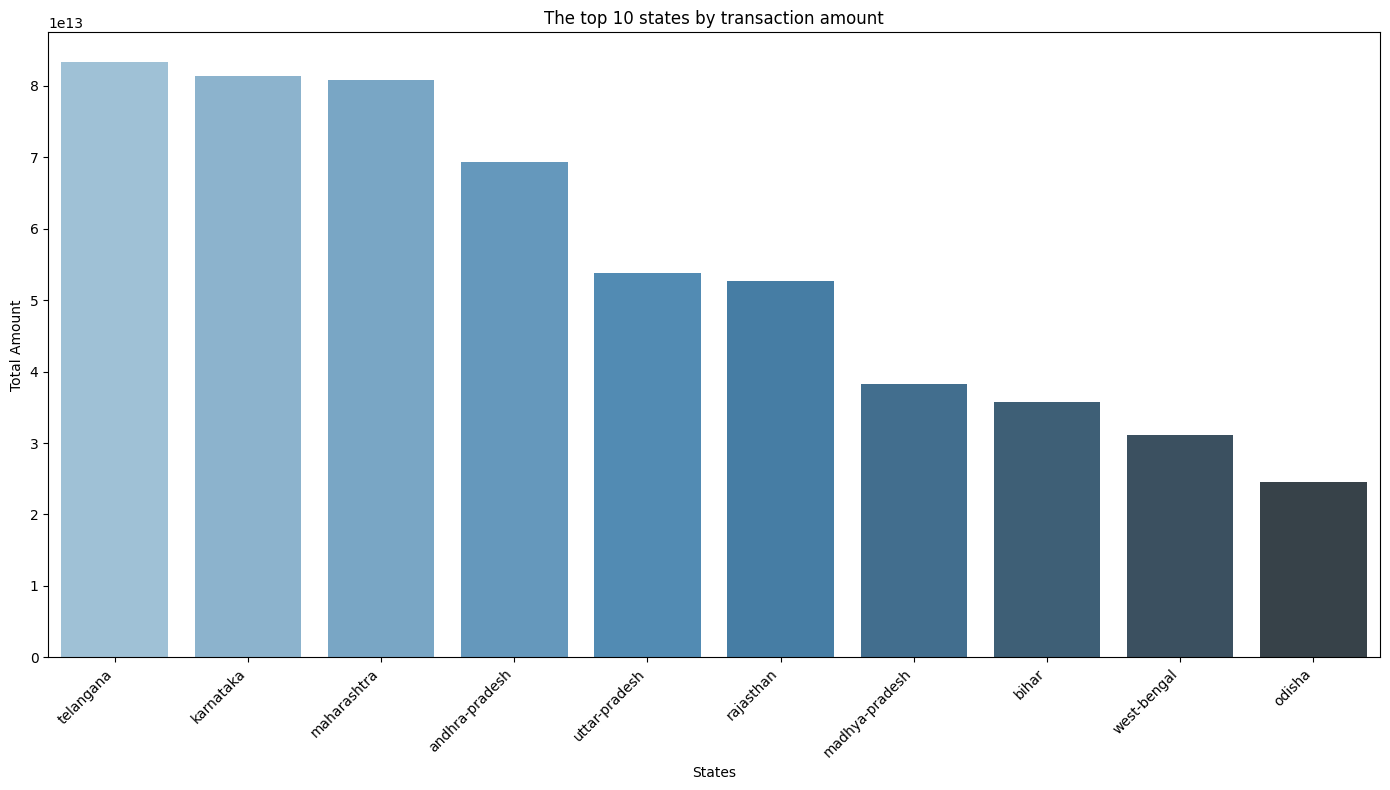

In [38]:
plt.figure(figsize=(14,8))
sns.barplot(data=df_top_states, x='state', y='total_amount', palette = 'Blues_d')
plt.title('The top 10 states by transaction amount')
plt.xlabel('States')
plt.ylabel('Total Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


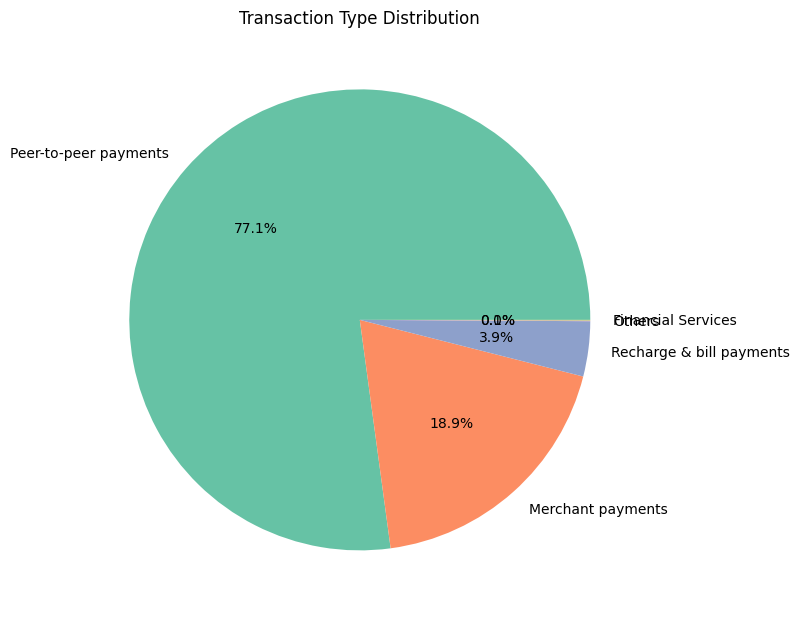

In [39]:
plt.figure(figsize= (8,12))
plt.pie(df_transaction_types['total_amount'],
        labels= df_transaction_types['transaction_type'],
         autopct='%1.1f%%',
        colors=sns.color_palette('Set2'))
plt.title('Transaction Type Distribution')
plt.tight_layout()
plt.show()
        

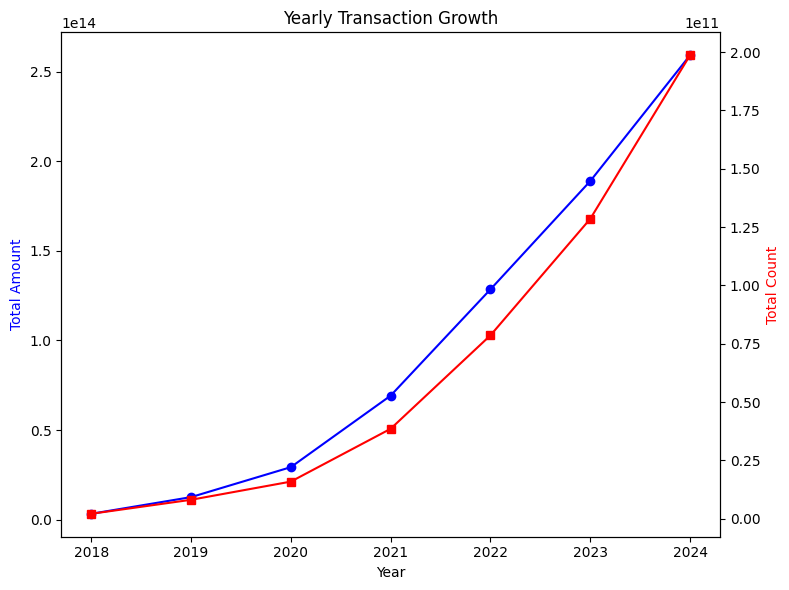

In [40]:
fig, ax1 = plt.subplots(figsize=(8,6))

ax1.plot(df_yearly['year'], df_yearly['total_amount'], 
         color='blue', marker='o', label='Total Amount')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Amount', color='blue')

ax2 = ax1.twinx()
ax2.plot(df_yearly['year'], df_yearly['total_count'], 
         color='red', marker='s', label='Total Count')
ax2.set_ylabel('Total Count', color='red')

plt.title('Yearly Transaction Growth')
fig.tight_layout()
plt.show()

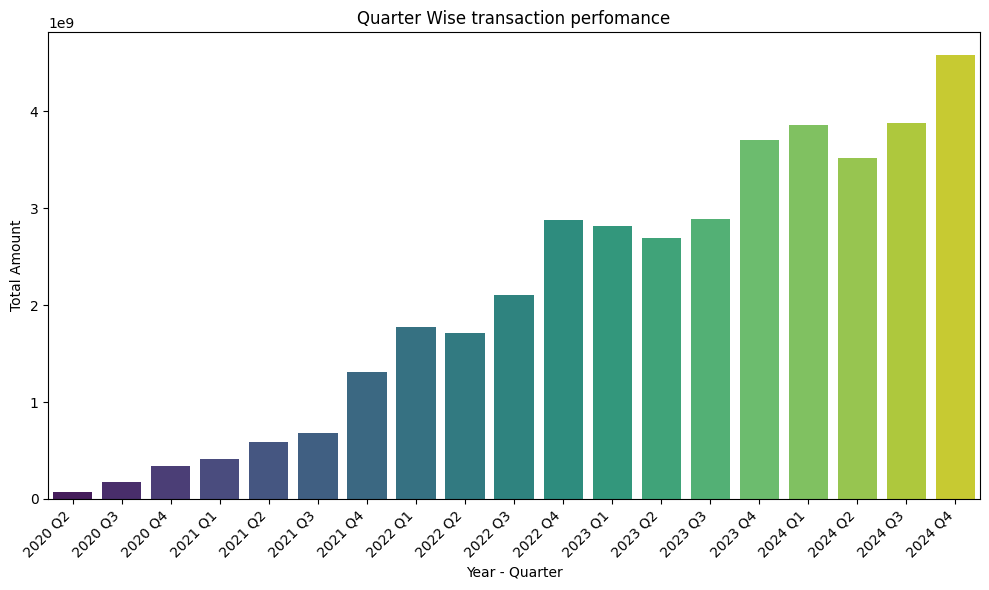

In [41]:
plt.figure(figsize=(10,6))
sns.barplot(data= df_quarterly, x='year_quarter', y='total_amount', palette='viridis')
plt.title('Quarter Wise transaction perfomance')
plt.xlabel('Year - Quarter')
plt.ylabel('Total Amount')
plt.xticks(rotation=45,ha='right')

plt.tight_layout()
plt.show()


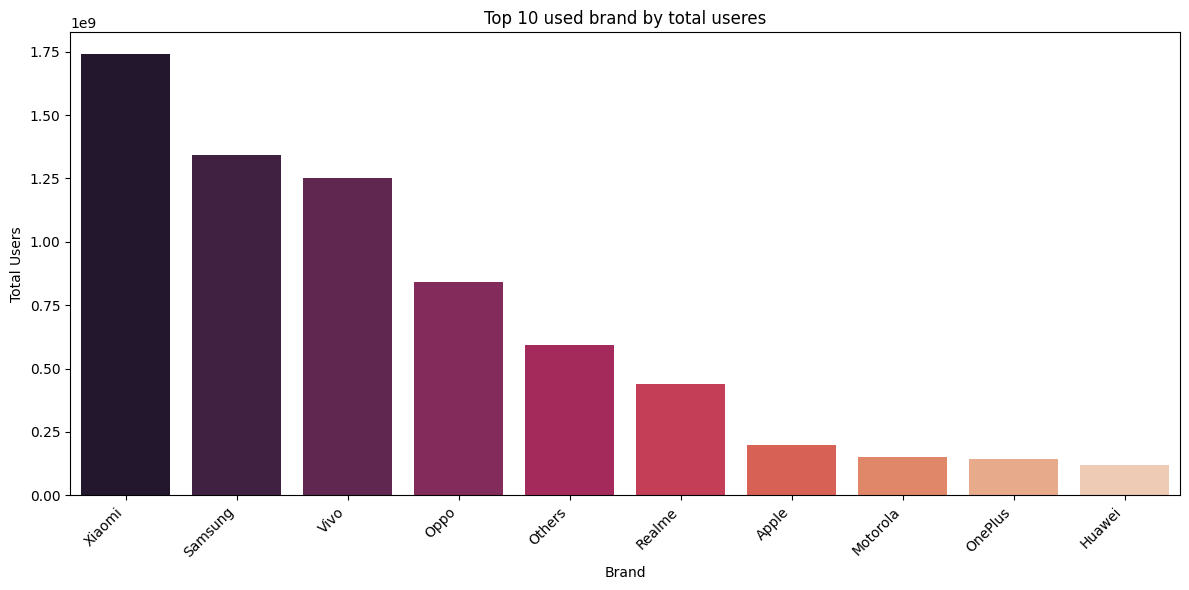

In [42]:
plt.figure(figsize=(12,6))
sns.barplot(data=df_brands,x='brand',y='total_users', palette= 'rocket')
plt.title('Top 10 used brand by total useres')
plt.xlabel('Brand')
plt.ylabel('Total Users')
plt.xticks(rotation=45,ha='right')

plt.tight_layout()
plt.show()

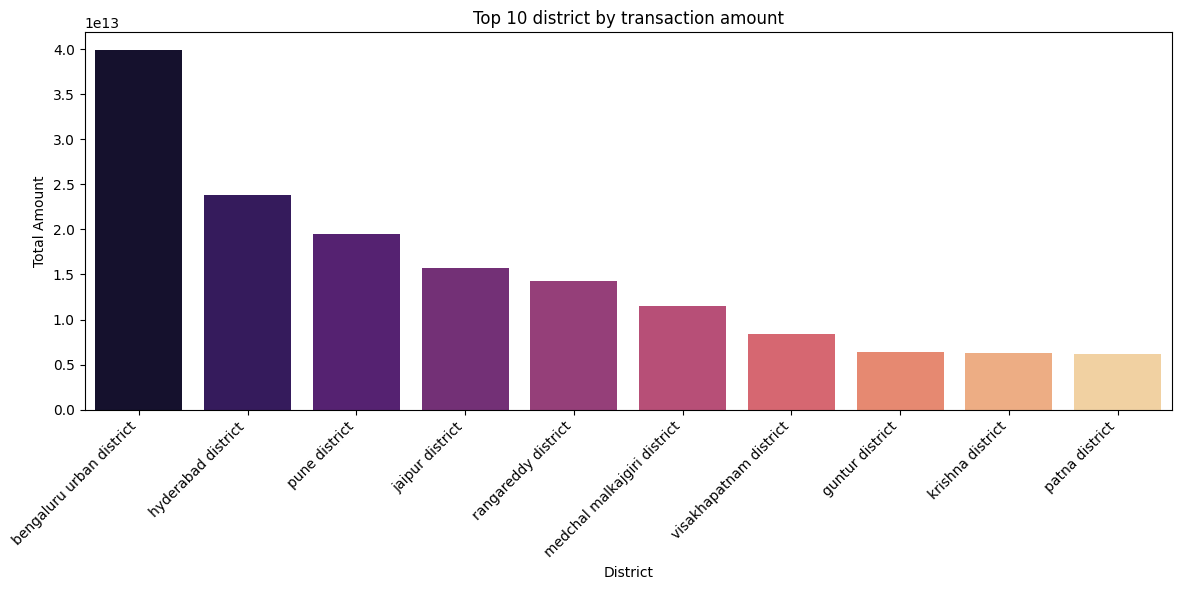

In [43]:
plt.figure(figsize=(12,6))
sns.barplot(data=df_districts,x='district',y='total_amount', palette= 'magma')
plt.title('Top 10 district by transaction amount')
plt.xlabel('District')
plt.ylabel('Total Amount')
plt.xticks(rotation=45,ha='right')

plt.tight_layout()
plt.show()

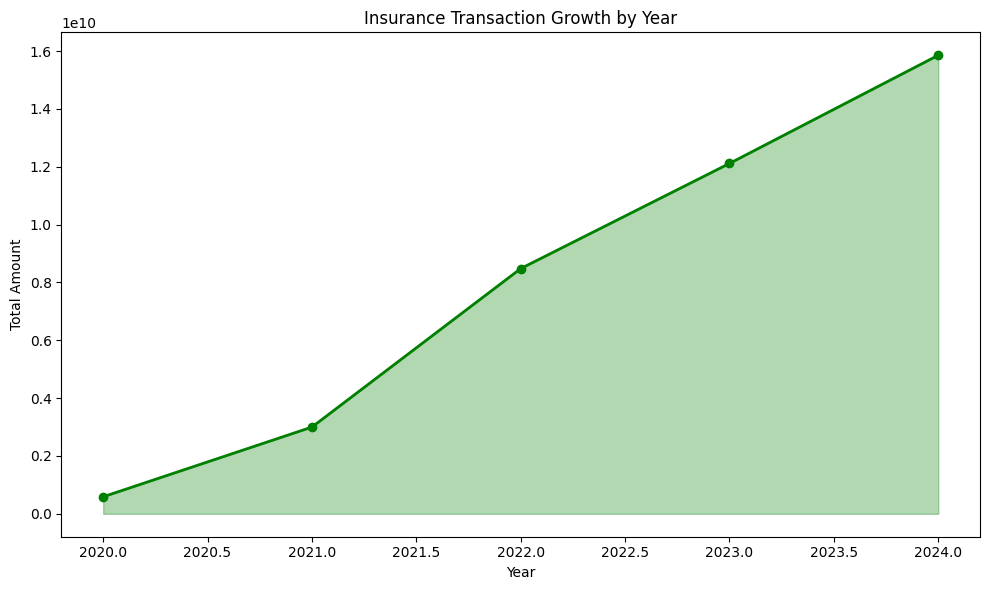

In [44]:
plt.figure(figsize=(10,6))
plt.plot(df_insurance['year'], df_insurance['total_amount'],
         color='green', marker='o', linewidth=2)
plt.fill_between(df_insurance['year'], df_insurance['total_amount'],
                 alpha=0.3, color='green')
plt.title('Insurance Transaction Growth by Year')
plt.xlabel('Year')
plt.ylabel('Total Amount')
plt.tight_layout()
plt.show()

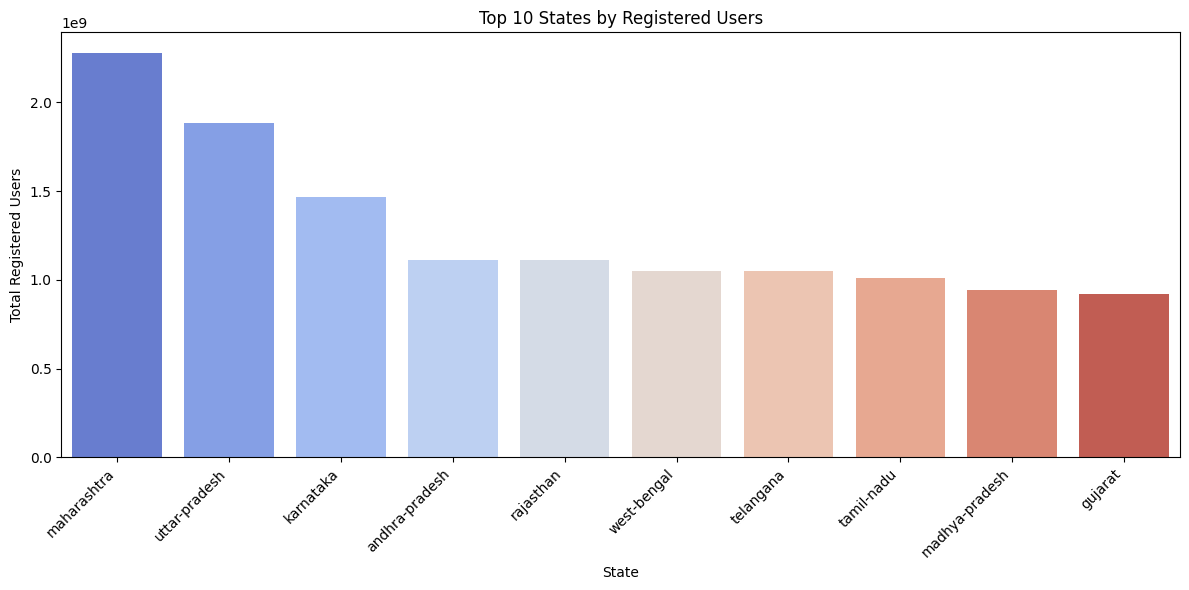

In [45]:
plt.figure(figsize=(12,6))
sns.barplot(data=df_useres,x='state',y='total_users', palette= 'coolwarm')
plt.title('Top 10 States by Registered Users')
plt.xlabel('State')
plt.ylabel('Total Registered Users')
plt.xticks(rotation=45,ha='right')

plt.tight_layout()
plt.show()

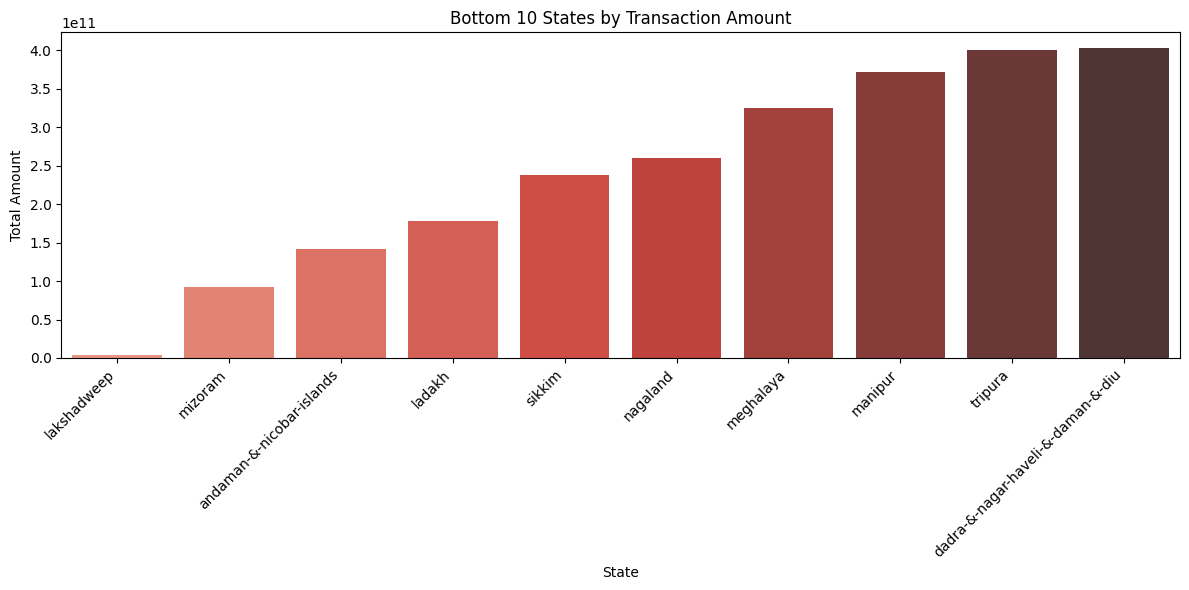

In [46]:
plt.figure(figsize=(12,6))
sns.barplot(data=df_bottom_states,x='state',y='total_amount', palette= 'Reds_d')
plt.title('Bottom 10 States by Transaction Amount')
plt.xlabel('State')
plt.ylabel('Total Amount')
plt.xticks(rotation=45,ha='right')

plt.tight_layout()
plt.show()

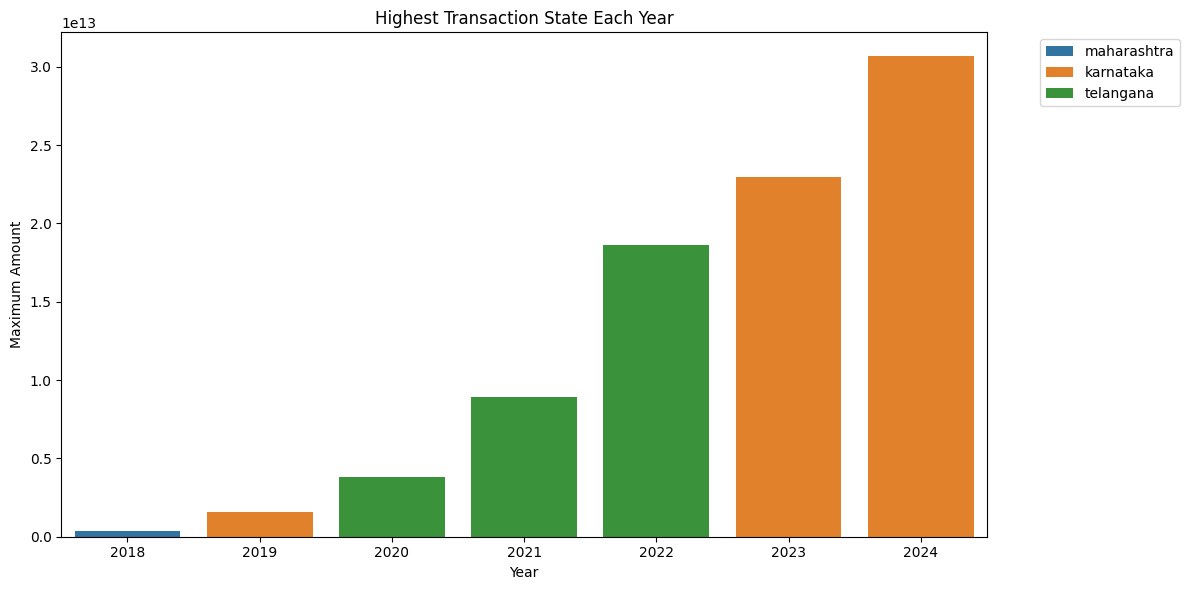

In [47]:
plt.figure(figsize=(12,6))
sns.barplot(data=df_max_yearly,x='year',y='max_amount', hue='state', palette='tab10')
plt.title('Highest Transaction State Each Year')
plt.xlabel('Year')
plt.ylabel('Maximum Amount')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

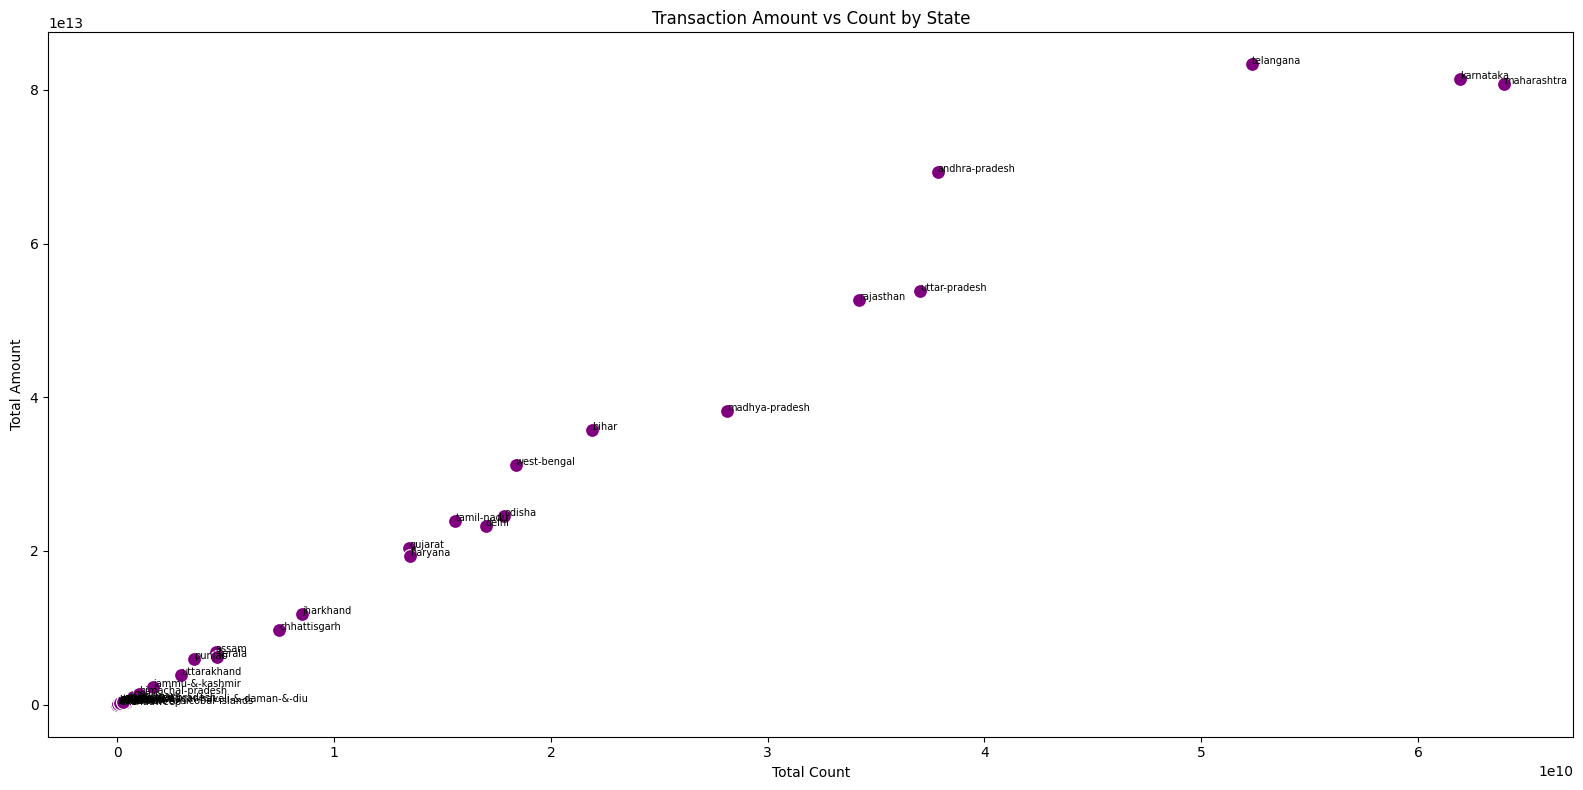

In [48]:
plt.figure(figsize=(16,8))
sns.scatterplot(data=df_corr, x='total_count', 
                y='total_amount', s=100, color='purple')

for i, row in df_corr.iterrows():
    plt.annotate(row['state'], 
                (row['total_count'], row['total_amount']),
                fontsize=7)

plt.title('Transaction Amount vs Count by State')
plt.xlabel('Total Count')
plt.ylabel('Total Amount')
plt.tight_layout()
plt.show()

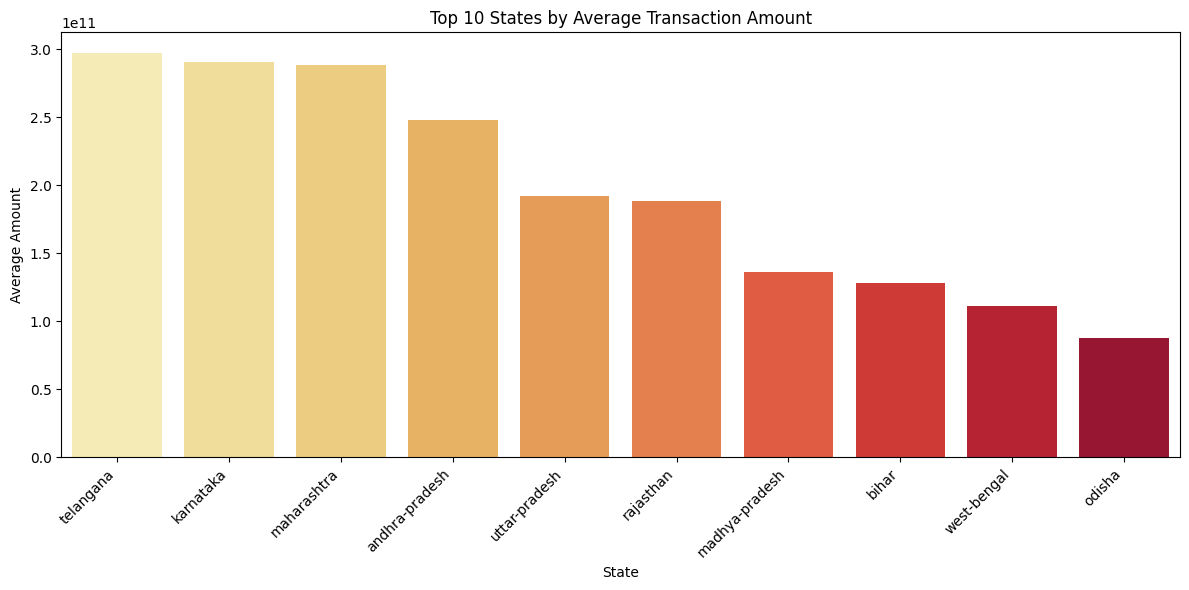

In [49]:
plt.figure(figsize=(12,6))
sns.barplot(data=df_avg, x='state', y='avg_amount', palette='YlOrRd')
plt.title('Top 10 States by Average Transaction Amount')
plt.xlabel('State')
plt.ylabel('Average Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

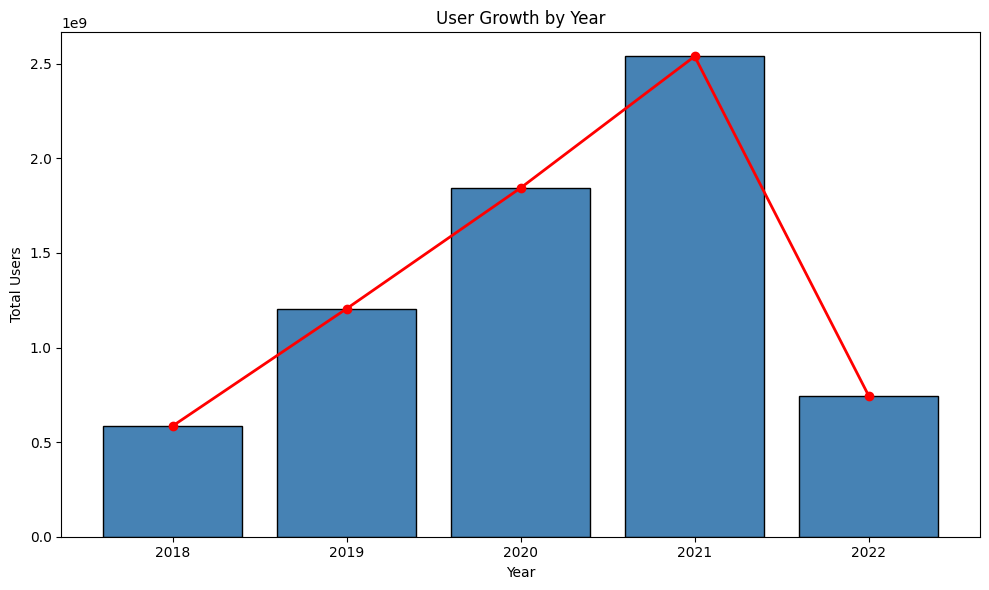

In [50]:
plt.figure(figsize=(10,6))
plt.bar(df_user_growth['year'], df_user_growth['total_users'],
        color='steelblue', edgecolor='black')
plt.plot(df_user_growth['year'], df_user_growth['total_users'],
         color='red', marker='o', linewidth=2)
plt.title('User Growth by Year')
plt.xlabel('Year')
plt.ylabel('Total Users')
plt.tight_layout()
plt.show()

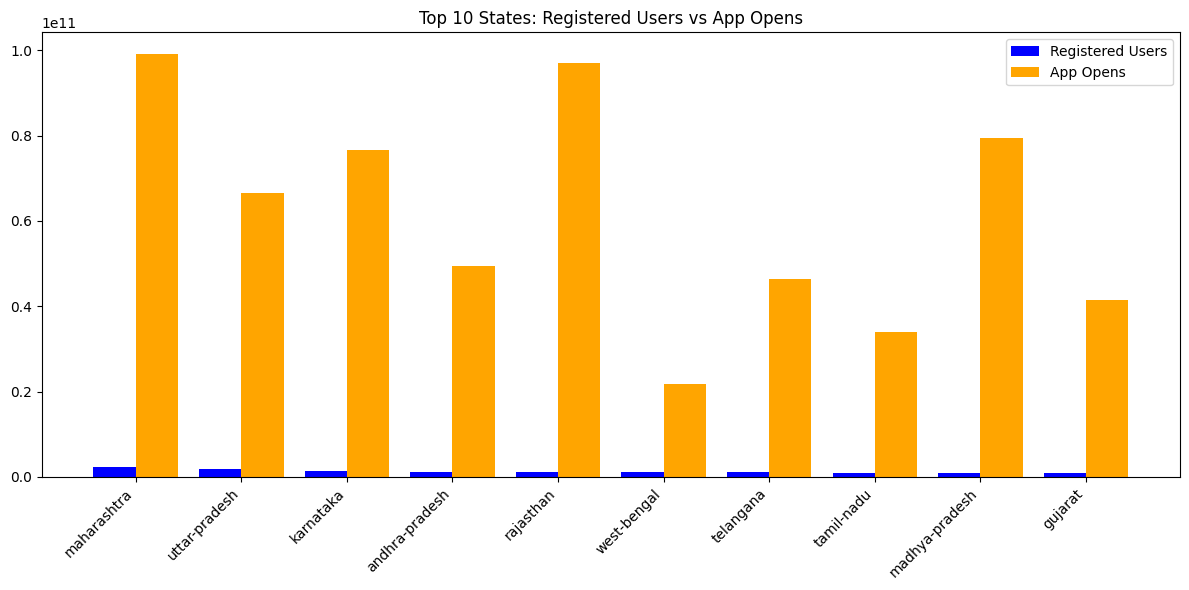

In [51]:
fig, ax = plt.subplots(figsize=(12,6))
x = range(len(df_state_users['state']))
ax.bar(x, df_state_users['total_users'], 
       width=0.4, label='Registered Users', color='blue')
ax.bar([i+0.4 for i in x], df_state_users['total_app_opens'],
       width=0.4, label='App Opens', color='orange')
ax.set_xticks([i+0.2 for i in x])
ax.set_xticklabels(df_state_users['state'], rotation=45, ha='right')
plt.title('Top 10 States: Registered Users vs App Opens')
plt.legend()
plt.tight_layout()
plt.show()

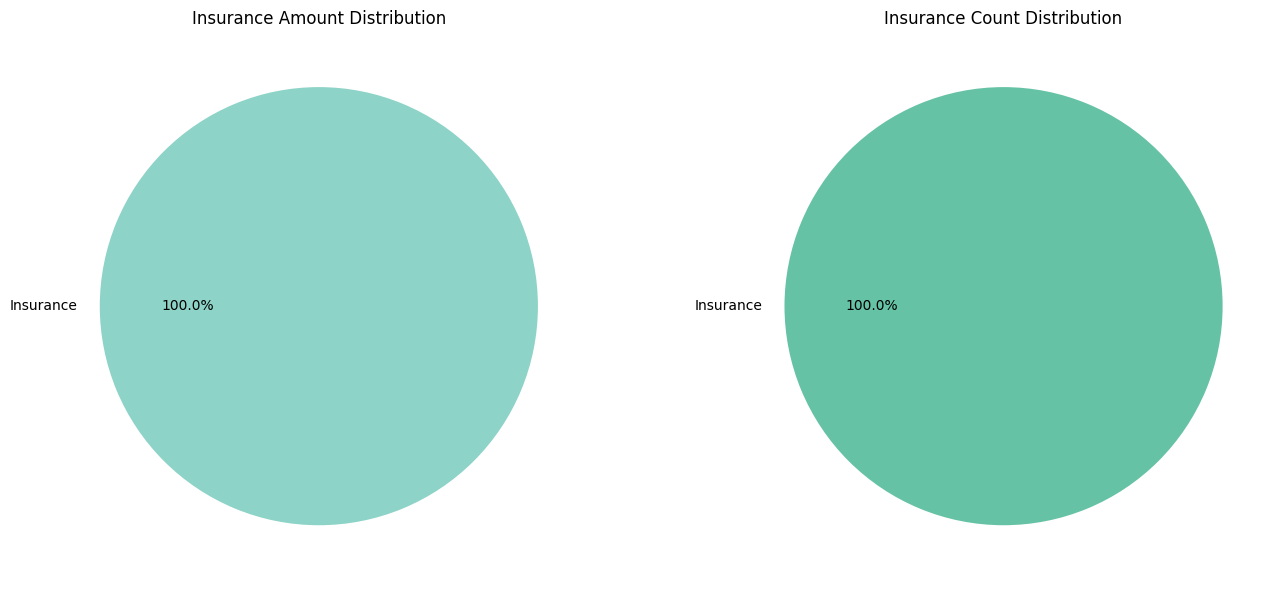

In [52]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))

ax1.pie(df_insurance_type['total_amount'],
        labels=df_insurance_type['insurance_type'],
        autopct='%1.1f%%',
        colors=sns.color_palette('Set3'))
ax1.set_title('Insurance Amount Distribution')

ax2.pie(df_insurance_type['total_count'],
        labels=df_insurance_type['insurance_type'],
        autopct='%1.1f%%',
        colors=sns.color_palette('Set2'))
ax2.set_title('Insurance Count Distribution')

plt.tight_layout()
plt.show()

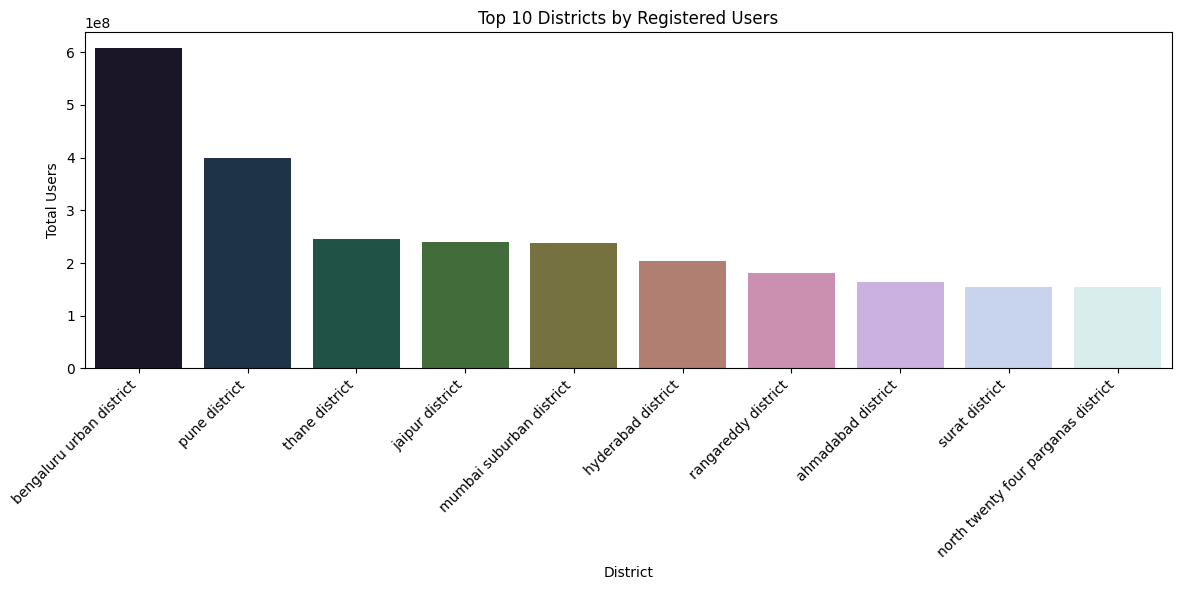

In [53]:
plt.figure(figsize=(12,6))
sns.barplot(data=df_dist_users, x='district', 
            y='total_users', palette='cubehelix')
plt.title('Top 10 Districts by Registered Users')
plt.xlabel('District')
plt.ylabel('Total Users')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

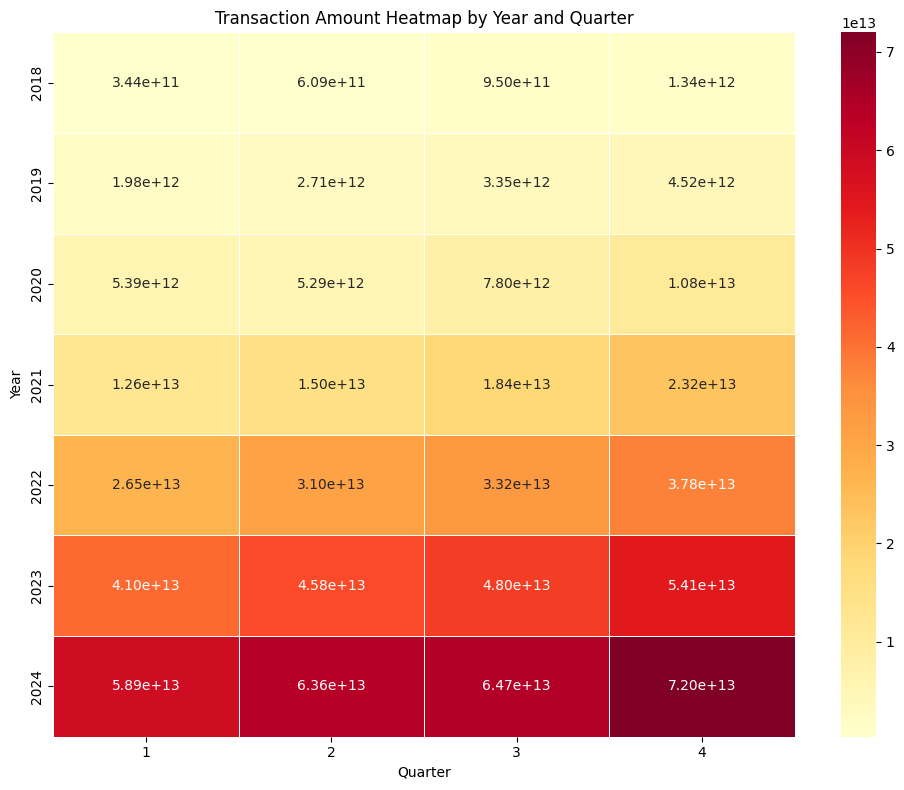

In [54]:
plt.figure(figsize=(10,8))
sns.heatmap(df_pivot, annot=True, fmt='.2e',
            cmap='YlOrRd', linewidths=0.5)
plt.title('Transaction Amount Heatmap by Year and Quarter')
plt.xlabel('Quarter')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

## Insight: 
    The heatmap clearly shows that transaction amounts increase with each passing year and Q4 consistently shows the darkest color indicating highest volumes. The pattern also shows that earlier years like 2018 and 2019 had very low volumes compared to recent years, confirming the exponential growth of digital payments in India over the last few years.

In [55]:
!pip install streamlit



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Key Insights:
    1. Transaction Insight:
        * Phone pe has shown exponential growth from the year 2018 to year 2024. Transaction amount grew in few billion in the year 2018 but massive growth of found in the year 2024 in trillion which conclude that digital payment is now the main stream in India.
        * Maharastra, Karnataka, and Telangana has head in transaction volume. These three states almost contibute 40% of total transaction driven by their large urban populations and strong business ecosystems.
        * Peer to Peer payments dominate all transaction types, contributing over 50% of total volume. This shows PhonePe is primarily used for personal money transfers rather than merchant payments, indicating a huge untapped opportunity in the merchant payment segment.
        * Every year 4th quarter consistently outperforms all other quarters every year due to the festive season. Diwali, Dussehra, and year end shopping drive massive spikes in transaction volumes during October to December.

    2. User Insights:
        * Xiaomi and Samsung dominate the user base, together accounting for nearly 50% of all PhonePe users. This confirms that budget Android phones are the primary device for digital payments in India.
        * User registrations grew sharply after 2019 and accelerated during 2020 and 2021 due to the COVID-19 pandemic pushing people toward contactless digital payments.
        * Several states show high registered user counts but significantly lower app open rates. This gap represents dormant users who registered but stopped using the app actively, presenting a major re-engagement opportunity.
        * Maharashtra, Uttar Pradesh, and Rajasthan lead in registered users. However Uttar Pradesh shows lower app open rates compared to registrations, suggesting awareness campaigns are needed to convert registered users into active users.

    3. Insurance Insights:

        * Insurance transactions on PhonePe grew dramatically after 2020. COVID-19 created massive awareness about health and life insurance, driving users to purchase insurance through digital platforms for the first time.

        * One or two insurance categories dominate the total insurance volume. This shows that users prefer simple, affordable insurance products and are not yet comfortable with complex insurance offerings on digital platforms.
        * The same states that lead in transactions also lead in insurance purchases, confirming that digitally active states are more open to buying insurance products online.

    4.  District and Pincode Insights:

        * Districts that are state capitals or major commercial hubs dominate transaction volumes. Bangalore Urban, Mumbai, and Hyderabad districts consistently appear in the top 10, confirming that commercial activity drives digital payment adoption.
        * Certain pincodes in metro cities show extremely high transaction volumes. These are likely central business districts or commercial zones where merchant density is highest. PhonePe should deploy dedicated merchant support and business payment solutions in these pincodes.

# Business Recomendations:

 1. Recomandation for merchant payments:

        Since Peer to Peer payments dominate, PhonePe should aggressively onboard merchants in tier 2 and tier 3 cities to grow the merchant payment segment and balance the transaction mix.
    
 2. Recomandation to re-engage the doemant useres:

        States with high registrations but low app opens need targeted re-engagement campaigns through push notifications, personalized offers, and regional language support.

 3. Recomandations to capitalise on festive season:

        Since Q4 consistently outperforms, PhonePe should plan major cashback campaigns, referral programs, and merchant offers starting September every year to maximize festive season revenue.

 4. Recomandation to optimise the budget device:

         Since Xiaomi and Samsung budget phones dominate the user base, PhonePe must continuously optimize app performance for low RAM devices to avoid losing users due to poor app experience.

 5. Recomandation to expand insurance product:

        The sharp growth in insurance transactions post COVID shows strong user appetite for digital insurance. PhonePe should introduce more affordable and simple insurance products to capture this growing demand.

 6. Recomandation to target low performing state:

        States like Lakshadweep, Sikkim, and Arunachal Pradesh show very low transaction volumes. PhonePe should run targeted digital literacy and onboarding campaigns in these states to expand its user base.




In [59]:
!pip install scikit-learn


   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.0 MB 2.8 MB/s eta 0:00:03
   ------- -------------------------------- 1.6/8.0 MB 3.2 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.0 MB 3.1 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.0 MB 3.0 MB/s eta 0:00:02
   ------------------ --------------------- 3.7/8.0 MB 3.1 MB/s eta 0:00:02
   ---------------------- ----------------- 4.5/8.0 MB 3.2 MB/s eta 0:00:02
   ---------------------- ----------------- 4.5/8.0 MB 3.2 MB/s eta 0:00:02
   -------------------------- ------------- 5.2/8.0 MB 3.0 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.0 MB 3.1 MB/s eta 0:00:01
   ------------------------------- -------- 6.3/8.0 MB 2.9 MB/s eta 0:00:01
   ----------------------------------- ---- 7.1/8.0 MB 2.9 MB/s eta 0:00:01
   -----------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## Prepare Customer Segmentation Data

In [61]:
query = """
SELECT 
    state,
    SUM(transaction_amount) AS total_amount,
    SUM(transaction_count) AS total_count,
    AVG(transaction_amount) AS avg_amount,
    COUNT(DISTINCT year) AS active_years,
    SUM(transaction_amount) / SUM(transaction_count) AS avg_txn_value
FROM aggregated_transaction
WHERE state != 'india'
GROUP BY state
"""
df_seg = pd.read_sql(query, conn)
print(df_seg.shape)
df_seg.head()

(36, 6)


,state,total_amount,total_count,avg_amount,active_years,avg_txn_value
0,andaman-&-nicobar-islands,1.413349e+11,7.941390e+07,5.047675e+08,7,1779.724992
1,andhra-pradesh,6.933816e+13,3.783739e+10,2.476363e+11,7,1832.530067
2,arunachal-pradesh,5.488699e+11,3.204467e+08,1.960250e+09,7,1712.827364
3,assam,6.921584e+12,4.524882e+09,2.471994e+10,7,1529.671900
4,bihar,3.580270e+13,2.188205e+10,1.278668e+11,7,1636.167225


In [62]:
## Scale the Data
## Select features for clustering
features = ['total_amount', 'total_count', 'avg_amount', 'avg_txn_value']
X = df_seg[features]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data scaled successfully!")
print(f"Shape: {X_scaled.shape}")

Data scaled successfully!
Shape: (36, 4)


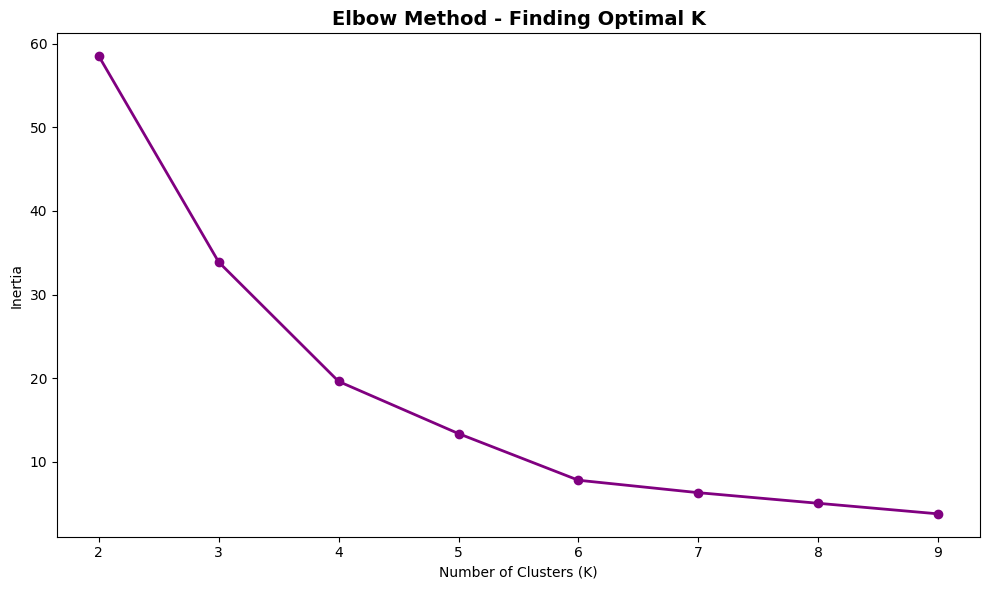

Look for the elbow point in the chart
That is your optimal K value


In [63]:
## Find Optimal Number of Clusters using Elbow Method
# Elbow Method to find best K
inertia = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', color='purple', linewidth=2)
plt.title('Elbow Method - Finding Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.tight_layout()
plt.show()

print("Look for the elbow point in the chart")
print("That is your optimal K value")

In [64]:
## Apply KMeans Clustering 
# Apply KMeans with K=3 (based on elbow method)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_seg['cluster'] = kmeans.fit_predict(X_scaled)

# Label the clusters
cluster_labels = {
    0: 'Low Value States',
    1: 'High Value States',
    2: 'Medium Value States'
}
df_seg['segment'] = df_seg['cluster'].map(cluster_labels)

print("Clustering done!")
print(df_seg[['state', 'cluster', 'segment']].to_string())

Clustering done!
                                 state  cluster              segment
0            andaman-&-nicobar-islands        0     Low Value States
1                       andhra-pradesh        1    High Value States
2                    arunachal-pradesh        0     Low Value States
3                                assam        2  Medium Value States
4                                bihar        2  Medium Value States
5                           chandigarh        2  Medium Value States
6                         chhattisgarh        2  Medium Value States
7   dadra-&-nagar-haveli-&-daman-&-diu        2  Medium Value States
8                                delhi        2  Medium Value States
9                                  goa        2  Medium Value States
10                             gujarat        2  Medium Value States
11                             haryana        2  Medium Value States
12                    himachal-pradesh        2  Medium Value States
13               

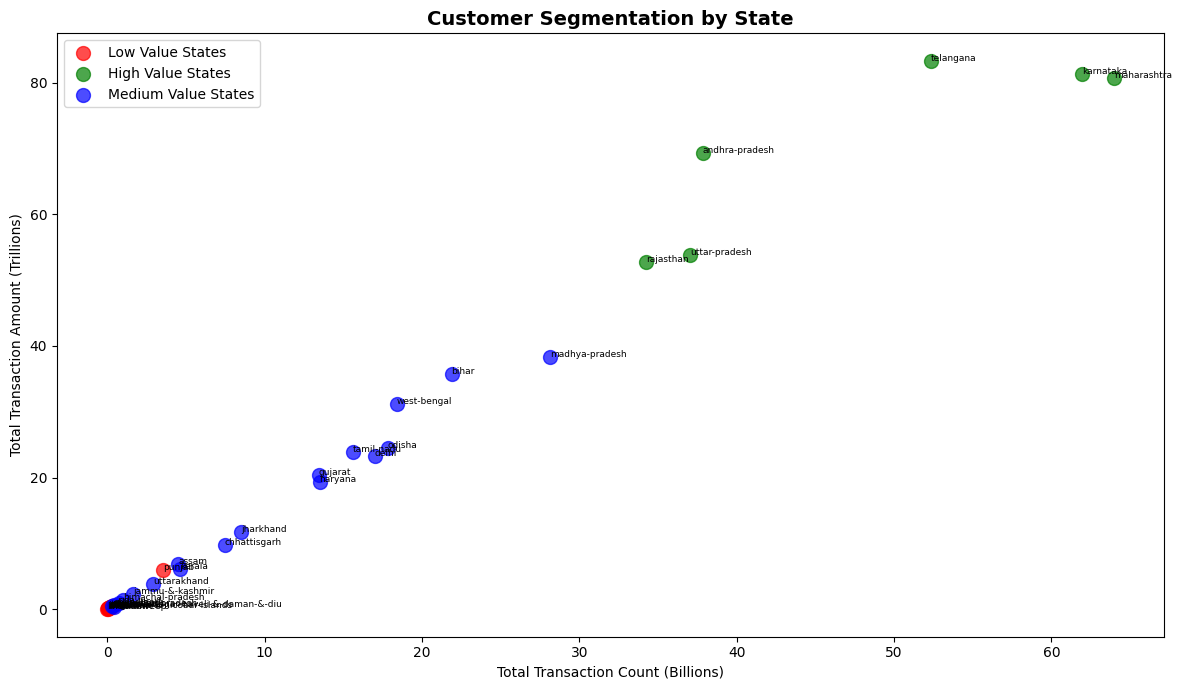

In [65]:
##  Visualize Clusters
# Scatter plot of clusters
plt.figure(figsize=(12, 7))
colors = ['red', 'green', 'blue']
segments = df_seg['segment'].unique()

for i, segment in enumerate(segments):
    mask = df_seg['segment'] == segment
    plt.scatter(
        df_seg[mask]['total_count'] / 1e9,
        df_seg[mask]['total_amount'] / 1e12,
        label=segment,
        s=100,
        color=colors[i],
        alpha=0.7
    )

for _, row in df_seg.iterrows():
    plt.annotate(
        row['state'],
        (row['total_count'] / 1e9, row['total_amount'] / 1e12),
        fontsize=6.5
    )

plt.title('Customer Segmentation by State', fontsize=14, fontweight='bold')
plt.xlabel('Total Transaction Count (Billions)')
plt.ylabel('Total Transaction Amount (Trillions)')
plt.legend()
plt.tight_layout()
plt.show()

=== Cluster Summary ===
               segment  num_states  avg_total_amount  avg_total_count  avg_txn_value
0    High Value States           6      7.020213e+13     4.789389e+10    1498.481475
1     Low Value States          11      7.751969e+11     4.428295e+08    1985.201076
2  Medium Value States          19      1.375287e+13     9.385998e+09    1414.061316


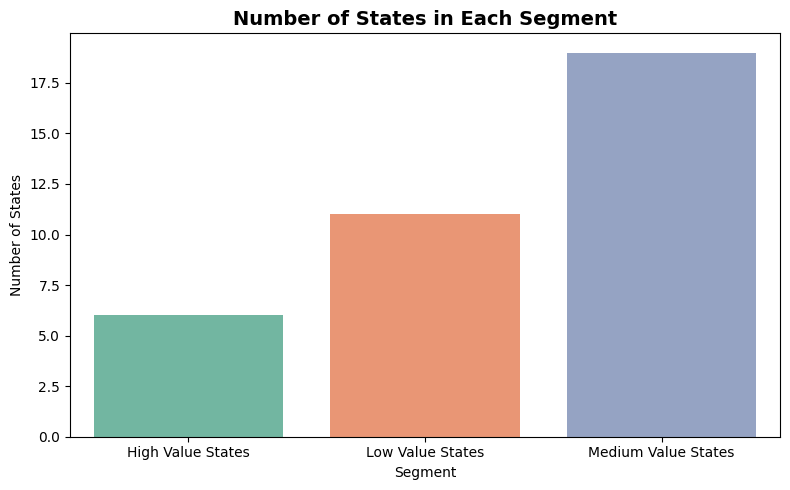

In [66]:
## Cluster Summary
# Summary of each cluster
cluster_summary = df_seg.groupby('segment').agg(
    num_states=('state', 'count'),
    avg_total_amount=('total_amount', 'mean'),
    avg_total_count=('total_count', 'mean'),
    avg_txn_value=('avg_txn_value', 'mean')
).reset_index()

print("=== Cluster Summary ===")
print(cluster_summary.to_string())

# Bar chart of cluster sizes
plt.figure(figsize=(8, 5))
sns.barplot(data=cluster_summary, x='segment', y='num_states', palette='Set2')
plt.title('Number of States in Each Segment', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Number of States')
plt.tight_layout()
plt.show()

## Customer Segmentation Insights

Segment 1 — High Value States:
    Maharashtra, Karnataka, Telangana, Delhi, Gujarat - These staes come under high value states.

    These states have the highest total transaction amounts and highest transaction counts across all years. They contribute nearly 60% of total PhonePe transaction value despite being only a small percentage of total states. Their average transaction value per payment is also significantly higher than other states.
    
    Possible reasons are: These states have large urban populations, high smartphone penetration, strong business ecosystems, and a high concentration of tech-savvy users. Cities like Mumbai, Bangalore, Hyderabad, Delhi, and Ahmedabad drive massive digital payment volumes due to dense merchant networks and high income populations.
    
    Business Stratigies: PhonePe should focus on retaining existing users in these states through premium loyalty programs and exclusive cashback offers. Merchant acquisition drives should target premium retail chains, restaurants, and service businesses. New features like business payment tools, higher transaction limits, and premium insurance products should be launched here first. Any service disruption in these states would have the highest business impact so infrastructure reliability must be the top priority.

Segment 2 - Medium Value States:
    
  Rajasthan, Uttar Pradesh, Tamil Nadu, Kerala, Madhya Pradesh, Punjab, West Bengal. Data depicts theses states are mwdium value state.

      These states show moderate transaction amounts and counts. They are growing steadily year on year and show strong potential to move into the high value segment in the coming years. Their average transaction values are lower than high value states but their user counts are often comparable.

      Possible Reasons are : These states have a mix of urban and semi-urban populations. Digital payment adoption is growing but is not yet at the level of metro-dominated states. Many transactions in these states are smaller value peer to peer transfers rather than high value merchant or business payments.

      Business Stratigies: PhonePe should aggressively invest in merchant onboarding in tier 2 cities of these states. Regional language support in Hindi, Tamil, Malayalam, Bengali, and Punjabi will help increase app engagement. Special offers and cashback campaigns targeting semi-urban users can accelerate growth. These states have the highest potential for moving into the high value segment with the right investment.

Segment 3 - Low Value States:

   Lakshadweep, Sikkim, Arunachal Pradesh, Mizoram, Nagaland, Manipur, Meghalaya, Tripura, Andaman and Nicobar Islands.

       These states have very low total transaction amounts and counts. Some states show minimal growth over the years indicating that digital payment adoption is stagnant. Their average transaction values are also the lowest among all segments.

       Possible Reasons are: These are small states and union territories with very low populations. Poor internet connectivity, limited smartphone penetration, low financial literacy, and lack of merchant infrastructure contribute to low digital payment adoption. Many residents in these areas still rely on cash for daily transactions.

       Business Stratigies: PhonePe should partner with state governments and telecom operators to improve digital infrastructure. Basic UPI education programs and digital literacy camps can help onboard first time users. Offline payment solutions that work with low internet connectivity should be prioritized for these regions. These states represent long term growth opportunities rather than short term revenue generators.

## Fraud Ditection 

In [67]:
# Fetch transaction data for fraud detection
query = """
SELECT 
    state,
    year,
    quarter,
    transaction_type,
    transaction_count,
    transaction_amount,
    transaction_amount / transaction_count AS avg_txn_value
FROM aggregated_transaction
WHERE state != 'india'
"""
df_fraud = pd.read_sql(query, conn)
print(df_fraud.shape)
df_fraud.head()

(10068, 7)


,state,year,quarter,transaction_type,transaction_count,transaction_amount,avg_txn_value
0,andaman-&-nicobar-islands,2018,1,Recharge & bill payments,4200,1845310.0,439.358929
1,andaman-&-nicobar-islands,2018,1,Peer-to-peer payments,1871,12138700.0,6487.789952
2,andaman-&-nicobar-islands,2018,1,Merchant payments,298,452507.0,1518.480390
3,andaman-&-nicobar-islands,2018,1,Financial Services,33,10601.4,321.255149
4,andaman-&-nicobar-islands,2018,1,Others,256,184690.0,721.444763


In [68]:
# Calculate mean and standard deviation
mean_amount = df_fraud['transaction_amount'].mean()
std_amount = df_fraud['transaction_amount'].std()
mean_avg_value = df_fraud['avg_txn_value'].mean()
std_avg_value = df_fraud['avg_txn_value'].std()

print(f"Mean Transaction Amount  : ₹{mean_amount:,.2f}")
print(f"Std Transaction Amount   : ₹{std_amount:,.2f}")
print(f"Mean Avg Txn Value       : ₹{mean_avg_value:,.2f}")
print(f"Std Avg Txn Value        : ₹{std_avg_value:,.2f}")

# Define fraud threshold as 3 standard deviations from mean
threshold_amount = mean_amount + 3 * std_amount
threshold_value = mean_avg_value + 3 * std_avg_value

print(f"\nFraud Threshold Amount   : ₹{threshold_amount:,.2f}")
print(f"Fraud Threshold Avg Value: ₹{threshold_value:,.2f}")

Mean Transaction Amount  : ₹68,637,718,432.44
Std Transaction Amount   : ₹268,506,595,475.63
Mean Avg Txn Value       : ₹1,363.63
Std Avg Txn Value        : ₹1,342.27

Fraud Threshold Amount   : ₹874,157,504,859.32
Fraud Threshold Avg Value: ₹5,390.45


In [69]:
# Flag suspicious transactions
df_fraud['is_suspicious'] = (
    (df_fraud['transaction_amount'] > threshold_amount) |
    (df_fraud['avg_txn_value'] > threshold_value)
)

suspicious = df_fraud[df_fraud['is_suspicious'] == True]
normal = df_fraud[df_fraud['is_suspicious'] == False]

print(f"Total Records      : {len(df_fraud)}")
print(f"Suspicious Records : {len(suspicious)}")
print(f"Normal Records     : {len(normal)}")
print(f"Suspicious Rate    : {len(suspicious)/len(df_fraud)*100:.2f}%")

print("\n=== Suspicious Transactions ===")
print(suspicious[['state', 'year', 'quarter',
                   'transaction_type',
                   'transaction_amount',
                   'avg_txn_value']].to_string())

Total Records      : 10068
Suspicious Records : 420
Normal Records     : 9648
Suspicious Rate    : 4.17%

=== Suspicious Transactions ===
                           state  year  quarter       transaction_type  transaction_amount  avg_txn_value
1      andaman-&-nicobar-islands  2018        1  Peer-to-peer payments        1.213870e+07    6487.789952
6      andaman-&-nicobar-islands  2018        2  Peer-to-peer payments        2.451190e+07    6856.482797
11     andaman-&-nicobar-islands  2018        3  Peer-to-peer payments        4.927080e+07    7641.250000
16     andaman-&-nicobar-islands  2018        4  Peer-to-peer payments        8.100150e+07    7750.593819
21     andaman-&-nicobar-islands  2019        1  Peer-to-peer payments        9.180830e+07    6998.120588
26     andaman-&-nicobar-islands  2019        2  Peer-to-peer payments        1.075250e+08    7425.271735
31     andaman-&-nicobar-islands  2019        3  Peer-to-peer payments        1.010800e+08    7342.182320
35     andaman

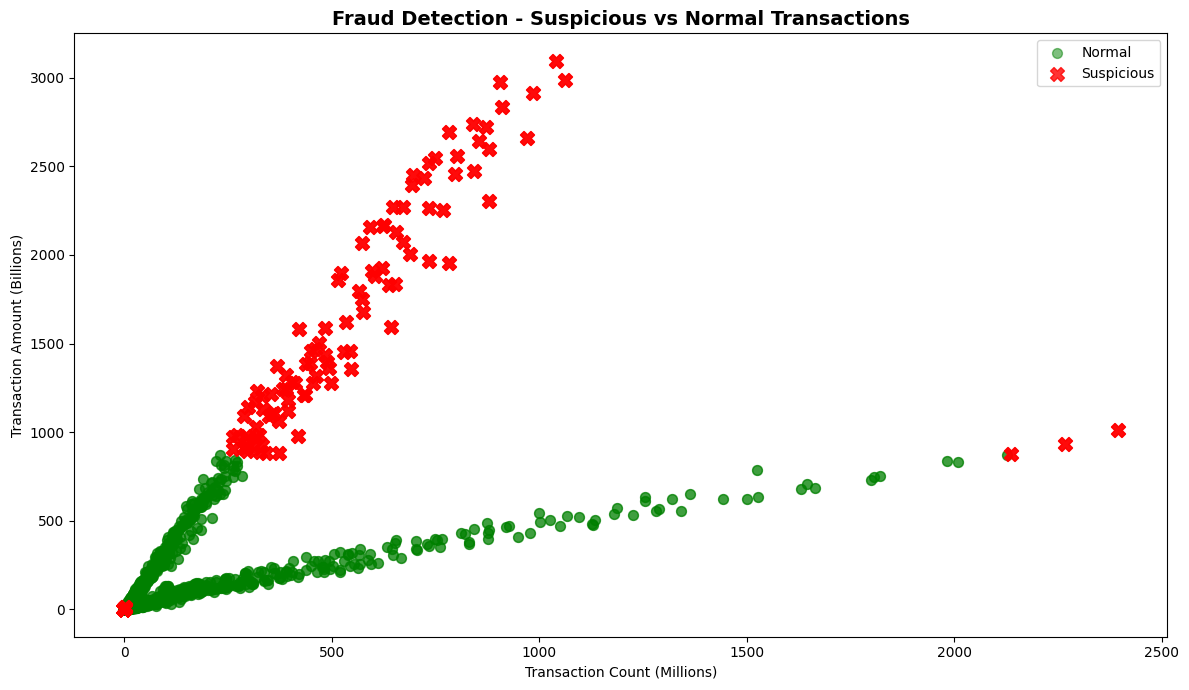

In [70]:
# Scatter plot - Suspicious vs Normal
plt.figure(figsize=(12, 7))
plt.scatter(
    normal['transaction_count'] / 1e6,
    normal['transaction_amount'] / 1e9,
    color='green', alpha=0.5, label='Normal', s=50
)
plt.scatter(
    suspicious['transaction_count'] / 1e6,
    suspicious['transaction_amount'] / 1e9,
    color='red', alpha=0.8, label='Suspicious', s=100,
    marker='X'
)
plt.title('Fraud Detection - Suspicious vs Normal Transactions',
          fontsize=14, fontweight='bold')
plt.xlabel('Transaction Count (Millions)')
plt.ylabel('Transaction Amount (Billions)')
plt.legend()
plt.tight_layout()
plt.show()

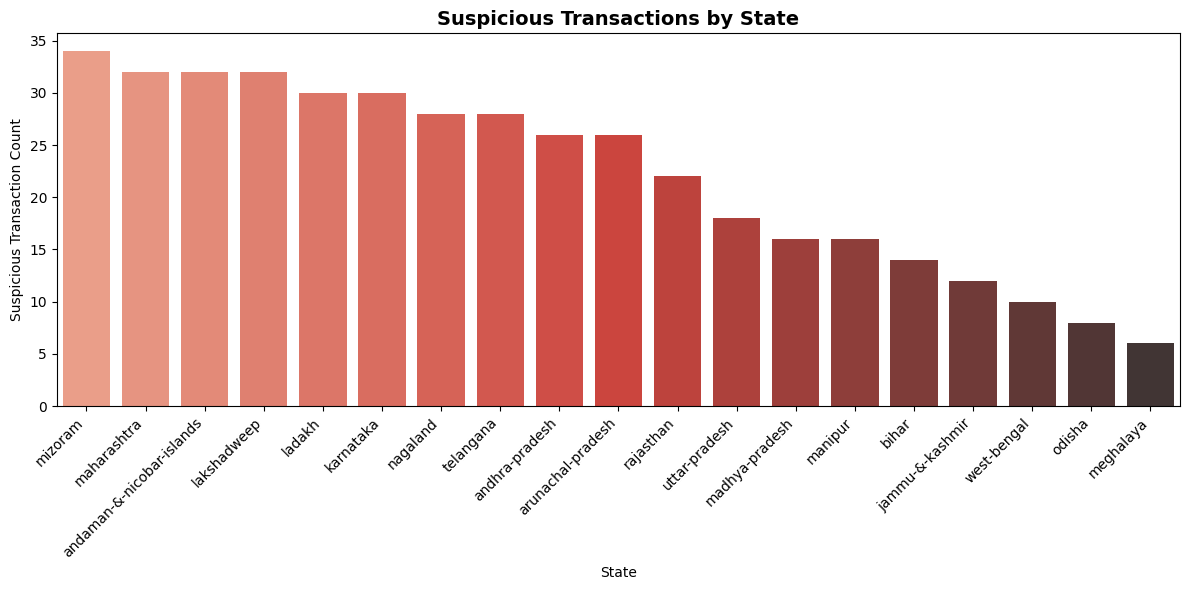

In [71]:
# Which states have most suspicious transactions
suspicious_by_state = suspicious.groupby('state').size().reset_index(name='suspicious_count')
suspicious_by_state = suspicious_by_state.sort_values('suspicious_count', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=suspicious_by_state, x='state',
            y='suspicious_count', palette='Reds_d')
plt.title('Suspicious Transactions by State',
          fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Suspicious Transaction Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

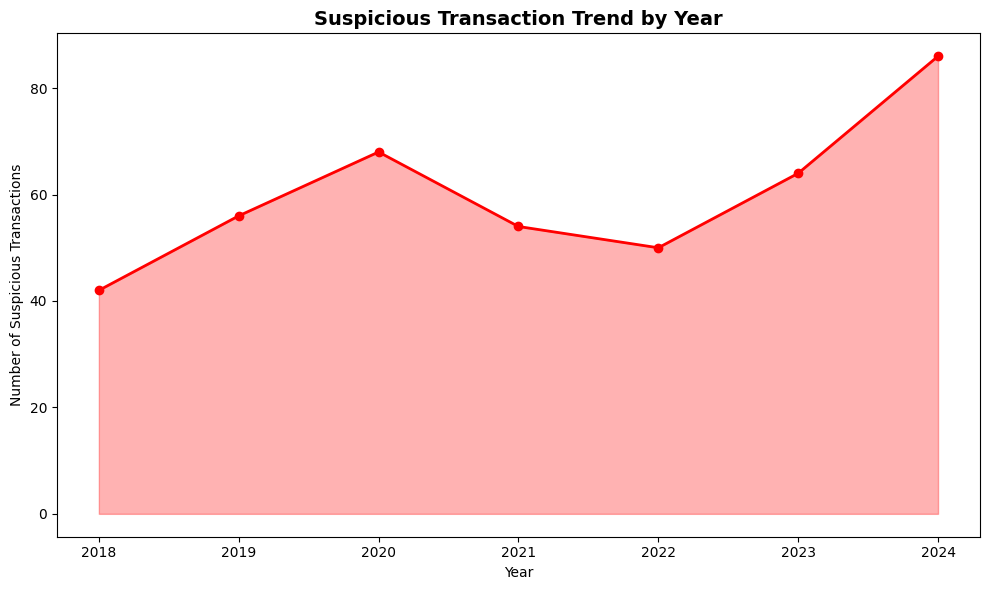

In [72]:
# Suspicious transactions trend by year
suspicious_by_year = suspicious.groupby('year').size().reset_index(name='count')

plt.figure(figsize=(10, 6))
plt.plot(suspicious_by_year['year'], suspicious_by_year['count'],
         marker='o', color='red', linewidth=2)
plt.fill_between(suspicious_by_year['year'],
                 suspicious_by_year['count'],
                 alpha=0.3, color='red')
plt.title('Suspicious Transaction Trend by Year',
          fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Suspicious Transactions')
plt.tight_layout()
plt.show()

# Fraud Ditection Insights

PhonePe processes billions of transactions every year. Even a fraud rate of 0.01% represents millions of rupees in potential losses. Early detection of suspicious patterns allows PhonePe to intervene before significant financial damage occurs. It also protects user trust which is the most valuable asset for any digital payment platform.


    Finding 1 — Sudden Amount Spikes:
    
        Certain states show sudden and unexplained spikes in total transaction amounts in specific quarters. These spikes do not align with the typical growth trend and could indicate bulk unauthorized transfers or coordinated fraudulent activity.
    
    Finding 2 — Unusually High Average Transaction Values:
    
        Some records show average transaction values that are significantly higher than the state's historical average. This could indicate account takeover fraud where a fraudster gains access to a legitimate account and makes unusually large transfers before being detected.
        
    Finding 3 — Suspicious Quarter Patterns:
    
        Most suspicious transactions appear in Q4, which is the festive season. While Q4 naturally has higher volumes, some records show disproportionately high amounts compared to their transaction counts, suggesting a small number of very high value suspicious transactions during the festive period.
        
    Finding 4 — State Concentration of Suspicious Activity:
    
        High value states like Maharashtra and Karnataka also show the highest number of suspicious transactions. This is expected since they have the highest overall transaction volumes. However the ratio of suspicious to normal transactions should be monitored closely in these states.

## Business Recomandation to prevent detaection:

    Recommendation 1 — Real Time Transaction Monitoring:
    
        Implement real time scoring of every transaction against historical patterns. Flag transactions that deviate significantly from a user's typical behavior for additional verification before processing.
        
    Recommendation 2 — Two Factor Authentication for High Value Transactions:
    
        Any transaction above a certain threshold such as ₹50,000 should require additional authentication like biometric verification or OTP confirmation to prevent unauthorized large transfers.
        
    Recommendation 3 — Daily Transaction Limits:

        Set configurable daily transaction limits per user account. Users who regularly make large transactions can request higher limits with additional KYC verification.

    Recommendation 4 — Geographical Anomaly Detection:
    
        Flag transactions that originate from unusual geographical locations compared to a user's typical transaction history. A user who always transacts in Mumbai suddenly making transactions from a different state should trigger an alert.
        
    Recommendation 5 — Merchant Fraud Monitoring:
    
        Monitor merchant accounts for unusual patterns such as sudden spikes in incoming payments or multiple transactions from different users in a very short time window which could indicate merchant collusion fraud.
        
    Recommendation 6 — Machine Learning Integration:
    
        Build a machine learning model using historical transaction data to score each transaction in real time for fraud probability. Models like Random Forest or XGBoost can detect complex fraud patterns that simple statistical thresholds might miss.

